# VPIN Insider Trading: Multi-Market Fingerprinting

**Problem:** The original Gaga-vs-Bad-Bunny comparison failed because the data profiles are incompatible (32K trades over 3 days vs 1K trades over 225 days). Direct comparison is meaningless.

**Revised approach:** Use ALL Super Bowl LX halftime performer markets from `KXPERFORMSUPERBOWLB-26`. Group by information regime:

1. **NO-baseline** — Markets that resolved NO. No private info existed. VPIN spikes here are noise → defines the **null distribution**.
2. **YES-surprise** — Markets that resolved YES unexpectedly (Gaga, Ricky Martin). Private info existed (production staff, agents, venue insiders). If insiders traded, VPIN should be elevated *before* prices moved.
3. **YES-public** — Bad Bunny (announced headliner). Control — info was public from the start.

**External validation:** A documented Polymarket insider went 17/20 on this exact event. Insiders traded — the question is whether VPIN can detect them.

**Key metric:** Directional accuracy — when VPIN spikes, does signed_flow predict the next price move? If YES-surprise markets show 70% hit rate vs 50% in NO markets, that's 20pp of tradeable edge.

In [1]:
import sys
from pathlib import Path

_notebook_dir = Path(__file__).parent if "__file__" in dir() else Path.cwd()
_repo_root = str(_notebook_dir.parent) if _notebook_dir.name == "notebooks" else str(_notebook_dir)

_vpin_path = Path(_repo_root) / "src" / "analysis" / "util" / "vpin.py"
if not _vpin_path.exists():
    raise FileNotFoundError(
        f"Cannot find src/ at {_repo_root}. "
        "Run this notebook from the repo root or the notebooks/ directory."
    )

if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from dataclasses import asdict
from IPython.display import display

from src.analysis.util.vpin import vpin_cte
from src.indexers.kalshi.client import KalshiClient

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
EVENT_TICKER = "KXPERFORMSUPERBOWLB-26"
CACHE_DIR = Path(_repo_root) / "data" / "case_study"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Bad Bunny was the publicly announced headliner — control market
PUBLIC_YES_SUFFIXES = {"BAD"}
MIN_FETCH_VOLUME = 100_000

# --- Discover all markets in this event ---
with KalshiClient() as client:
    all_markets = client.list_markets(event_ticker=EVENT_TICKER, limit=200)

print(f"Found {len(all_markets)} markets in {EVENT_TICKER}\n")

market_catalog = {}
for m in sorted(all_markets, key=lambda x: x.volume, reverse=True):
    suffix = m.ticker.replace(f"{EVENT_TICKER}-", "")
    if m.result not in ("yes", "no"):
        group = "excluded"
    elif m.result == "no":
        group = "NO-baseline"
    elif suffix in PUBLIC_YES_SUFFIXES:
        group = "YES-public"
    else:
        group = "YES-surprise"

    market_catalog[m.ticker] = {
        "suffix": suffix,
        "title": m.title,
        "result": m.result,
        "volume": m.volume,
        "group": group,
    }
    vol_str = f"{m.volume:>10,}"
    print(f"  {suffix:12s}  {group:14s}  result={m.result:6s}  volume={vol_str}")


def fetch_or_load(ticker: str, suffix: str) -> pd.DataFrame:
    """Fetch trades from Kalshi API or load from parquet cache."""
    cache_path = CACHE_DIR / f"{suffix.lower()}_trades.parquet"
    if cache_path.exists():
        df = pd.read_parquet(cache_path)
        print(f"  {suffix}: loaded {len(df):,} trades from cache")
        return df

    with KalshiClient() as client:
        trades = client.get_market_trades(ticker)

    df = pd.DataFrame([asdict(t) for t in trades])
    df.to_parquet(cache_path, index=False)
    print(f"  {suffix}: fetched and cached {len(df):,} trades")
    return df


print("\n--- Fetching trades ---")
trade_dfs = {}
for ticker, info in market_catalog.items():
    if info["group"] == "excluded":
        print(f"  {info['suffix']}: excluded (result={info['result']})")
        continue
    if info["volume"] < MIN_FETCH_VOLUME:
        print(f"  {info['suffix']}: skipped (volume={info['volume']:,} < {MIN_FETCH_VOLUME:,})")
        continue
    trade_dfs[ticker] = fetch_or_load(ticker, info["suffix"])

# --- Summary table ---
print(f"\n--- {len(trade_dfs)} markets loaded ---")
rows = []
for ticker in trade_dfs:
    info = market_catalog[ticker]
    df = trade_dfs[ticker]
    ts = pd.to_datetime(df["created_time"])
    rows.append({
        "Ticker": info["suffix"],
        "Group": info["group"],
        "Result": info["result"],
        "Volume": f"{info['volume']:,}",
        "Trades": f"{len(df):,}",
        "Date range": f"{ts.min().date()} \u2192 {ts.max().date()}",
    })
pd.DataFrame(rows)

Found 54 markets in KXPERFORMSUPERBOWLB-26

  CAR           excluded        result=scalar  volume=21,021,545
  TRA           NO-baseline     result=no      volume= 9,655,419
  LAD           YES-surprise    result=yes     volume= 5,841,525
  KAR           NO-baseline     result=no      volume= 2,033,118
  RIC           YES-surprise    result=yes     volume= 1,454,626
  DRA           NO-baseline     result=no      volume= 1,153,948
  JBA           NO-baseline     result=no      volume=   925,231
  SHA           NO-baseline     result=no      volume=   849,627
  DAD           NO-baseline     result=no      volume=   569,321
  RAU           NO-baseline     result=no      volume=   441,488
  TAY           NO-baseline     result=no      volume=   295,078
  MAR           NO-baseline     result=no      volume=   235,918
  ARC           NO-baseline     result=no      volume=   227,122
  JHA           NO-baseline     result=no      volume=   178,959
  GRA           NO-baseline     result=no     

,Ticker,Group,Result,Volume,Trades,Date range
0,TRA,NO-baseline,no,"9,655,419","68,579",2025-09-29 → 2026-02-09
1,LAD,YES-surprise,yes,"5,841,525","32,125",2026-02-05 → 2026-02-09
2,KAR,NO-baseline,no,"2,033,118","21,857",2025-10-11 → 2026-02-09
3,RIC,YES-surprise,yes,"1,454,626","12,936",2026-02-04 → 2026-02-09
4,DRA,NO-baseline,no,"1,153,948","9,329",2025-06-12 → 2026-02-09
5,JBA,NO-baseline,no,"925,231","15,200",2025-10-22 → 2026-02-09
6,SHA,NO-baseline,no,"849,627","3,922",2026-02-04 → 2026-02-09
7,DAD,NO-baseline,no,"569,321","6,058",2025-09-29 → 2026-02-09
8,RAU,NO-baseline,no,"441,488","10,537",2025-10-03 → 2026-02-09
9,TAY,NO-baseline,no,"295,078","2,312",2025-08-07 → 2026-02-09


In [3]:
BUCKET_SIZE = 200
LOOKBACK = 10

# Build list of parquet paths for all fetched markets
parquet_paths = []
for ticker in trade_dfs:
    suffix = market_catalog[ticker]["suffix"]
    parquet_paths.append(str(CACHE_DIR / f"{suffix.lower()}_trades.parquet"))

paths_str = ", ".join(f"'{p}'" for p in parquet_paths)

con = duckdb.connect()
vpin_df = con.execute(f"""
    WITH trades AS (
        SELECT ticker, count, taker_side, yes_price, created_time
        FROM read_parquet([{paths_str}])
    ),
    {vpin_cte('trades', BUCKET_SIZE, LOOKBACK)}
    SELECT * FROM vpin_series WHERE window_size = {LOOKBACK}
""").df()
con.close()

# Split into per-market DataFrames
market_vpins = {}
for ticker in trade_dfs:
    mv = vpin_df[vpin_df["ticker"] == ticker].sort_values("bucket_id").reset_index(drop=True)
    market_vpins[ticker] = mv

# Group-level helpers (used by all experiments)
yes_surprise_tickers = [t for t in market_vpins if market_catalog[t]["group"] == "YES-surprise"]
no_baseline_tickers = [t for t in market_vpins if market_catalog[t]["group"] == "NO-baseline"]
yes_public_tickers = [t for t in market_vpins if market_catalog[t]["group"] == "YES-public"]

display_order = sorted(
    market_vpins.keys(),
    key=lambda t: (
        {"YES-surprise": 0, "YES-public": 1, "NO-baseline": 2}[market_catalog[t]["group"]],
        -market_catalog[t]["volume"],
    ),
)

# Pooled NO-baseline VPIN (null distribution)
no_vpin_pooled = np.concatenate([
    market_vpins[t]["vpin"].values for t in no_baseline_tickers
])
NO_P90 = float(np.percentile(no_vpin_pooled, 90))

# Print summary
for ticker in display_order:
    df = market_vpins[ticker]
    info = market_catalog[ticker]
    print(
        f"{info['suffix']:12s} ({info['group']:14s}): "
        f"{len(df):>6,} buckets  "
        f"VPIN=[{df['vpin'].min():.3f}, {df['vpin'].max():.3f}]  "
        f"signed_flow=[{df['signed_flow'].min():.3f}, {df['signed_flow'].max():.3f}]"
    )

print(f"\nPooled NO-baseline: {len(no_vpin_pooled):,} VPIN buckets, 90th pctile = {NO_P90:.4f}")

LAD          (YES-surprise  ):  8,549 buckets  VPIN=[0.570, 1.000]  signed_flow=[-1.000, 1.000]
RIC          (YES-surprise  ):  2,638 buckets  VPIN=[0.491, 1.000]  signed_flow=[-1.000, 0.999]
BAD          (YES-public    ):    207 buckets  VPIN=[0.523, 1.000]  signed_flow=[-0.971, 0.617]
TRA          (NO-baseline   ): 18,473 buckets  VPIN=[0.431, 1.000]  signed_flow=[-1.000, 1.000]
KAR          (NO-baseline   ):  3,848 buckets  VPIN=[0.439, 1.000]  signed_flow=[-1.000, 1.000]
DRA          (NO-baseline   ):  2,374 buckets  VPIN=[0.486, 1.000]  signed_flow=[-1.000, 1.000]
JBA          (NO-baseline   ):  2,432 buckets  VPIN=[0.342, 1.000]  signed_flow=[-1.000, 1.000]
SHA          (NO-baseline   ):  1,160 buckets  VPIN=[0.702, 1.000]  signed_flow=[-1.000, 1.000]
DAD          (NO-baseline   ):  1,280 buckets  VPIN=[0.496, 1.000]  signed_flow=[-1.000, 1.000]
RAU          (NO-baseline   ):  1,264 buckets  VPIN=[0.291, 1.000]  signed_flow=[-0.967, 1.000]
TAY          (NO-baseline   ):    554 bu

## Experiment 1: Timeline Panels

Visual inspection of price, VPIN, and signed flow over time for each market.

**What to look for:**
- **YES-surprise:** VPIN elevating *before* price surges, with signed_flow pointing in the direction of the eventual resolution
- **NO-baseline:** VPIN fluctuating randomly, no sustained directional flow
- The dashed threshold line (pooled NO 90th percentile) provides a common ruler across all markets

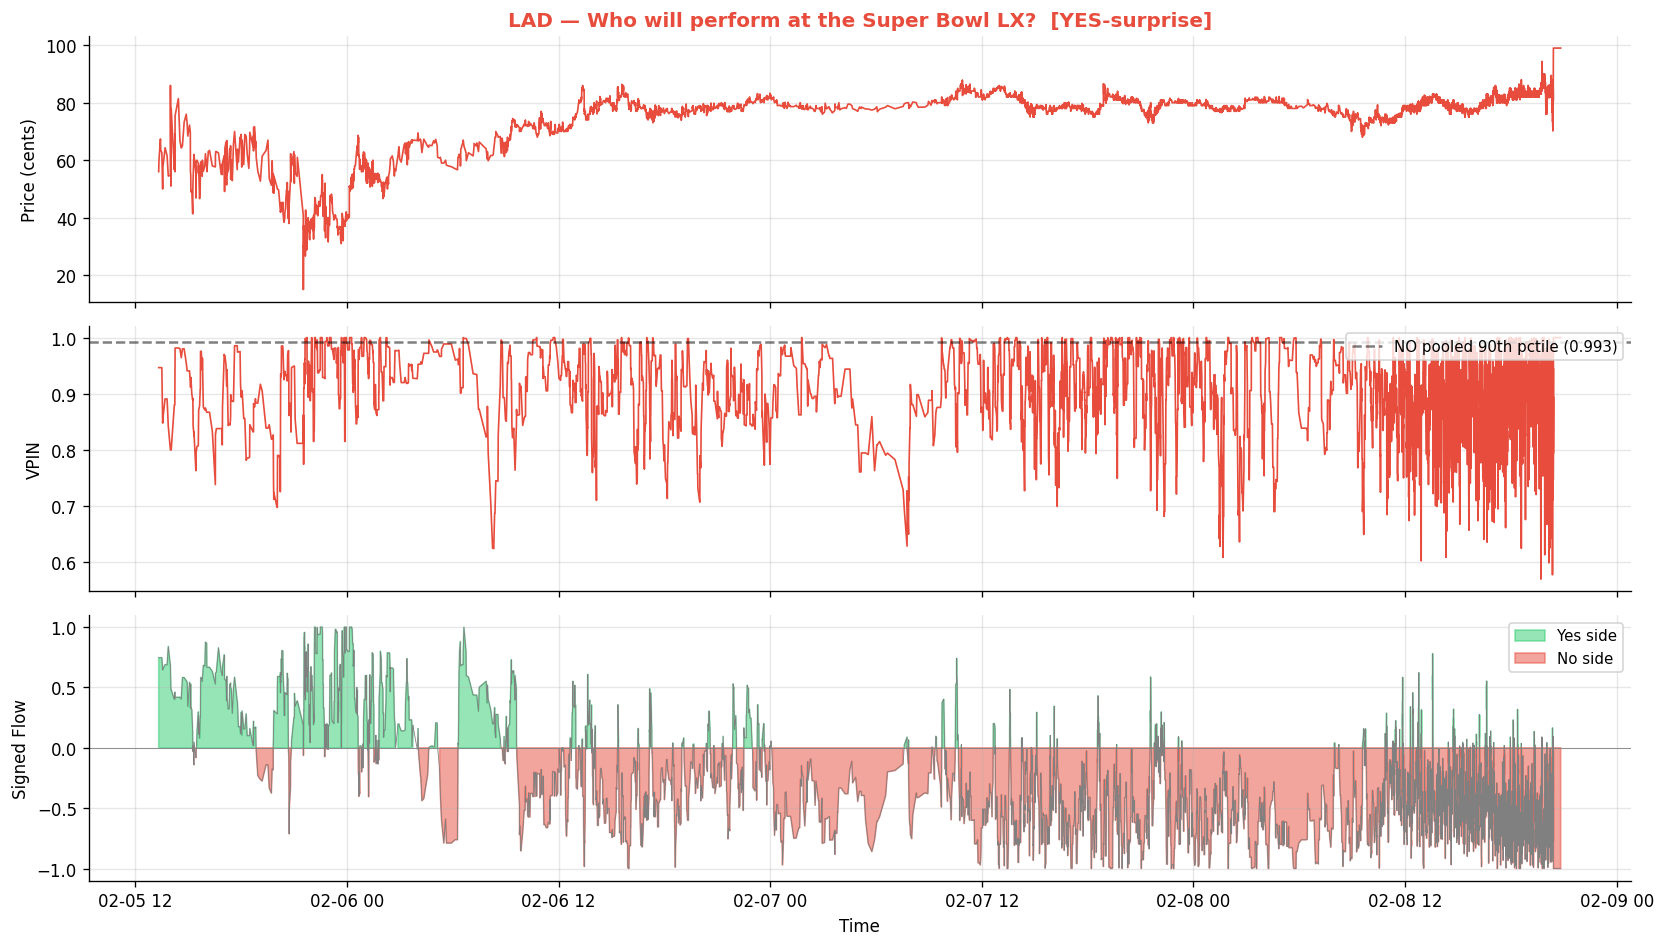

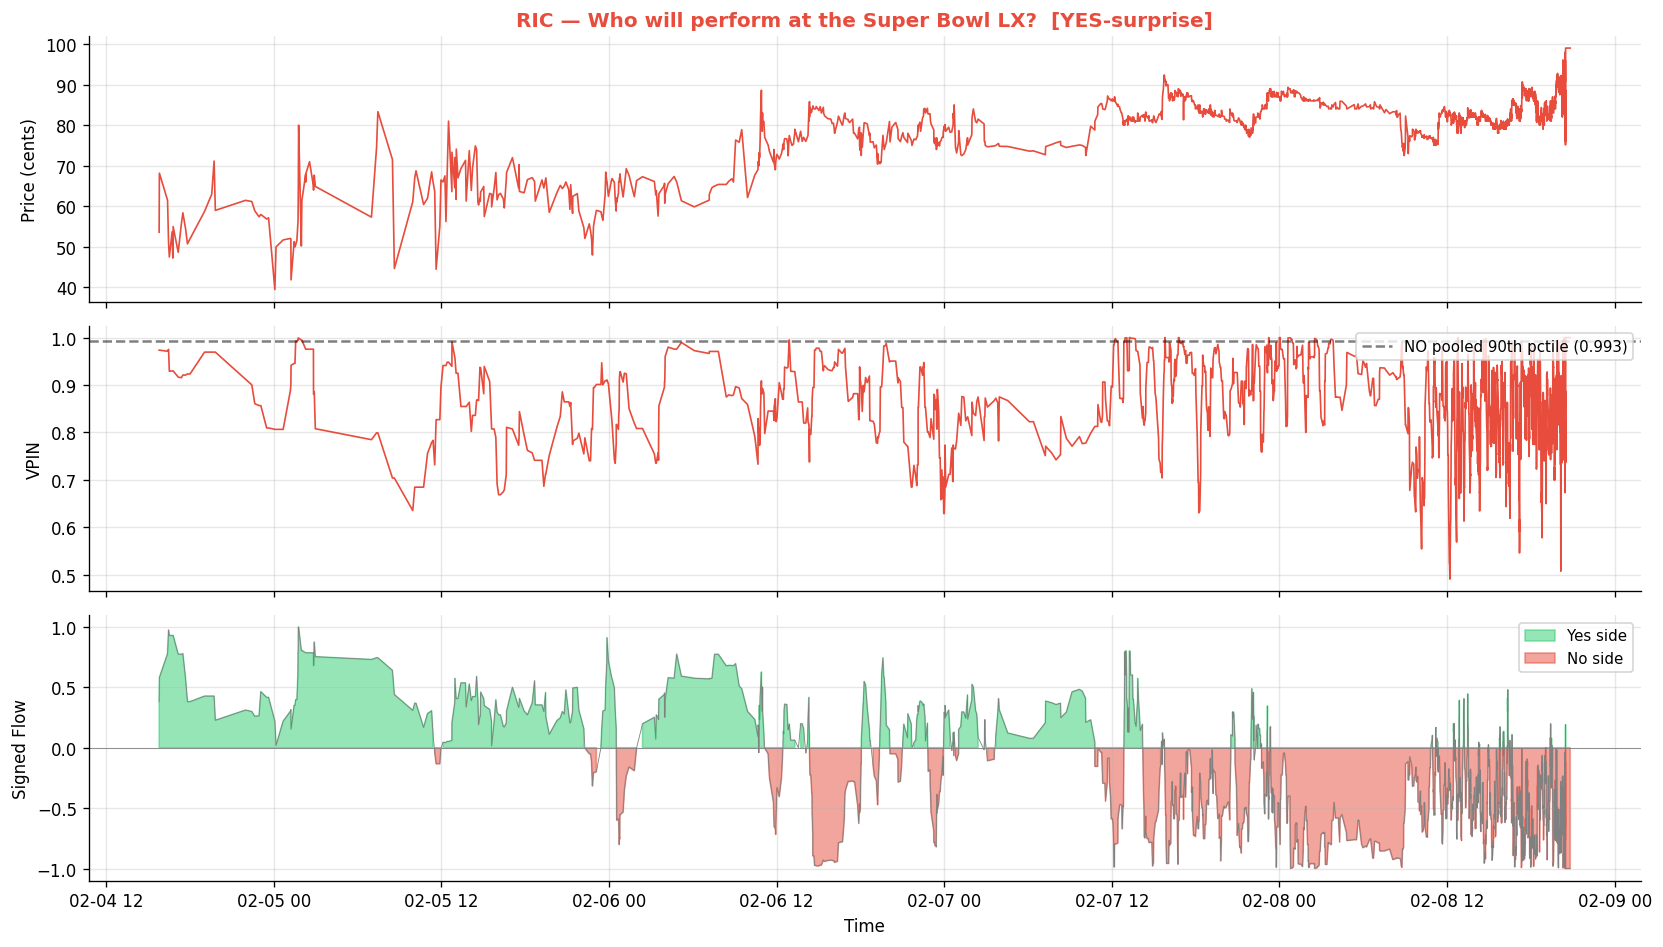

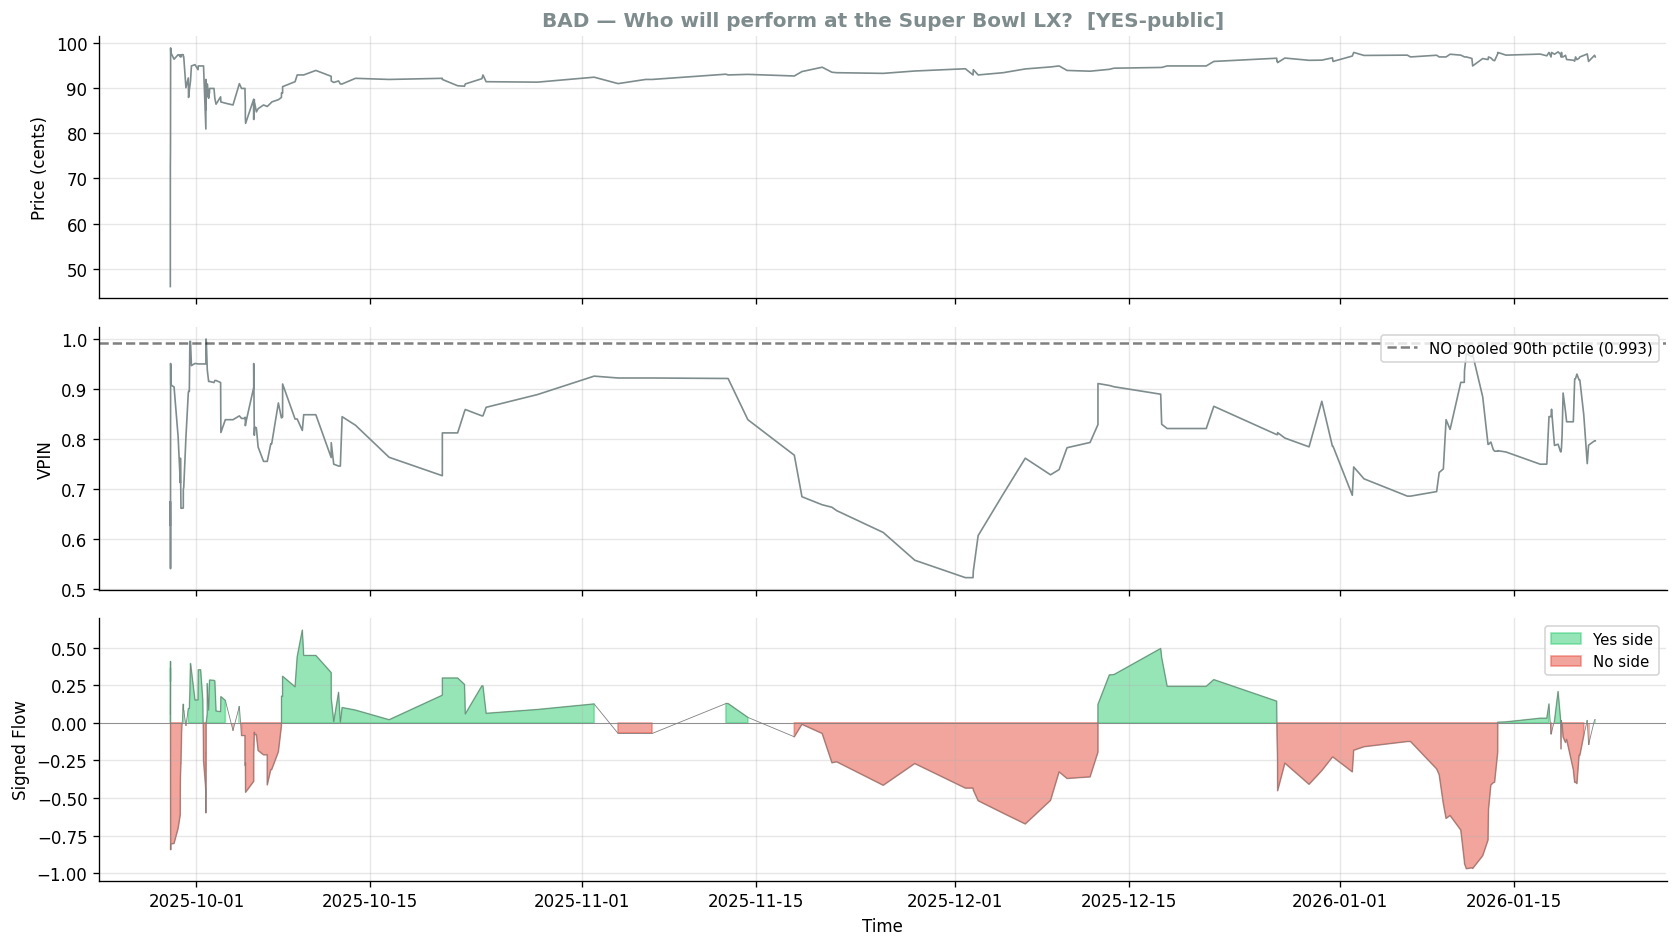

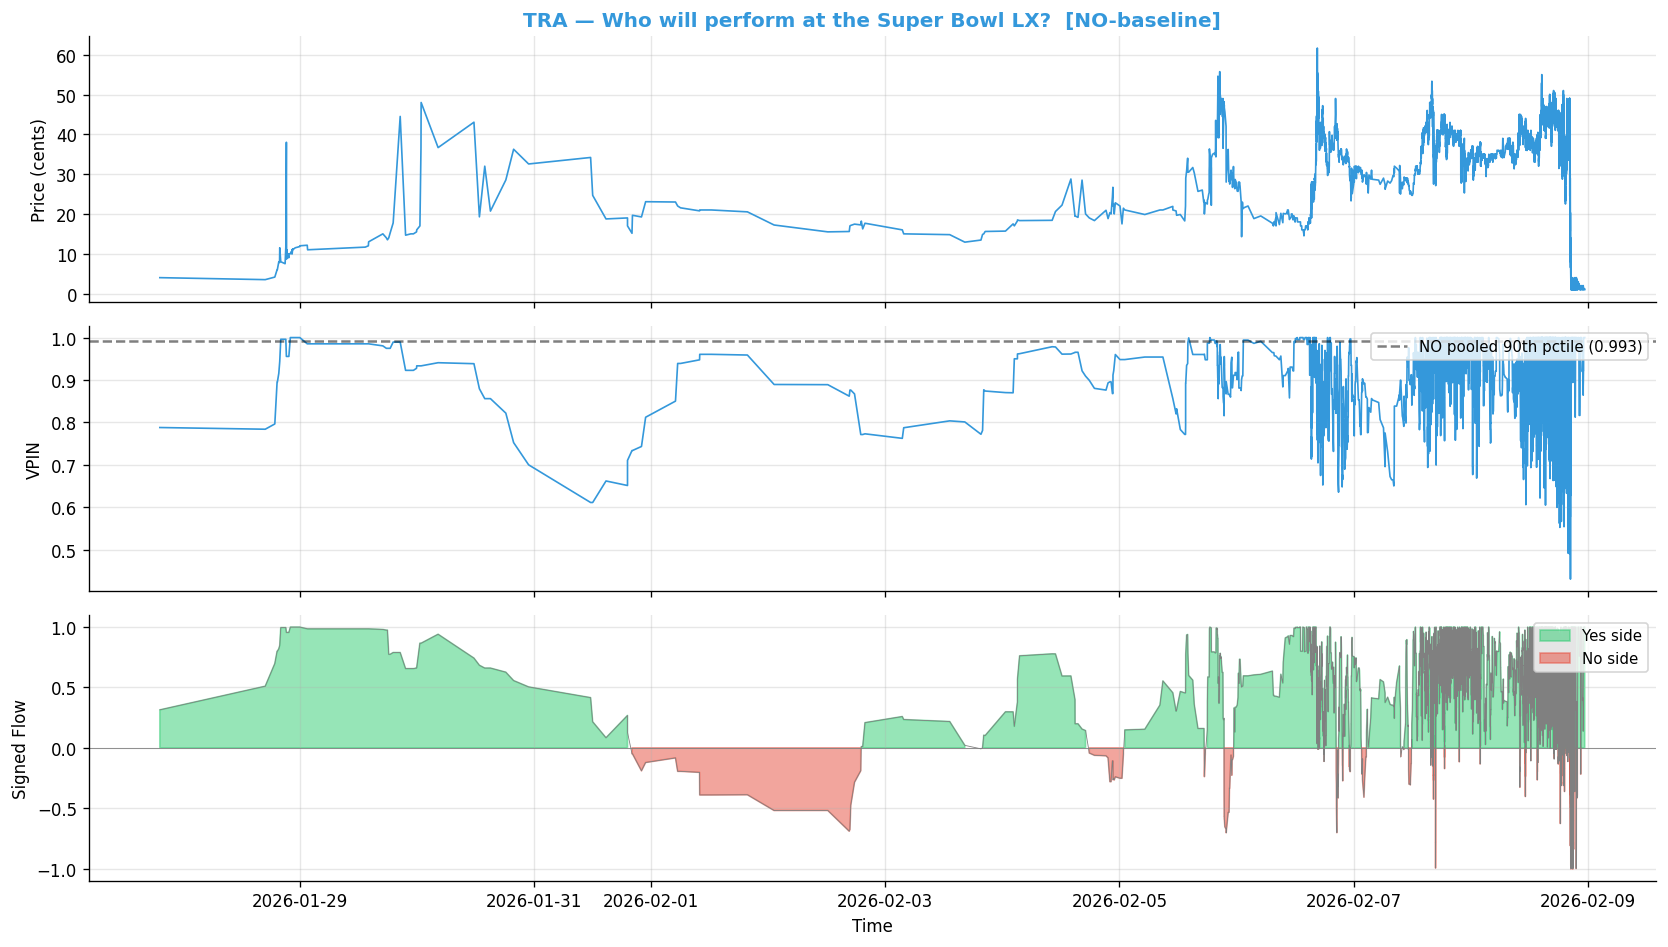

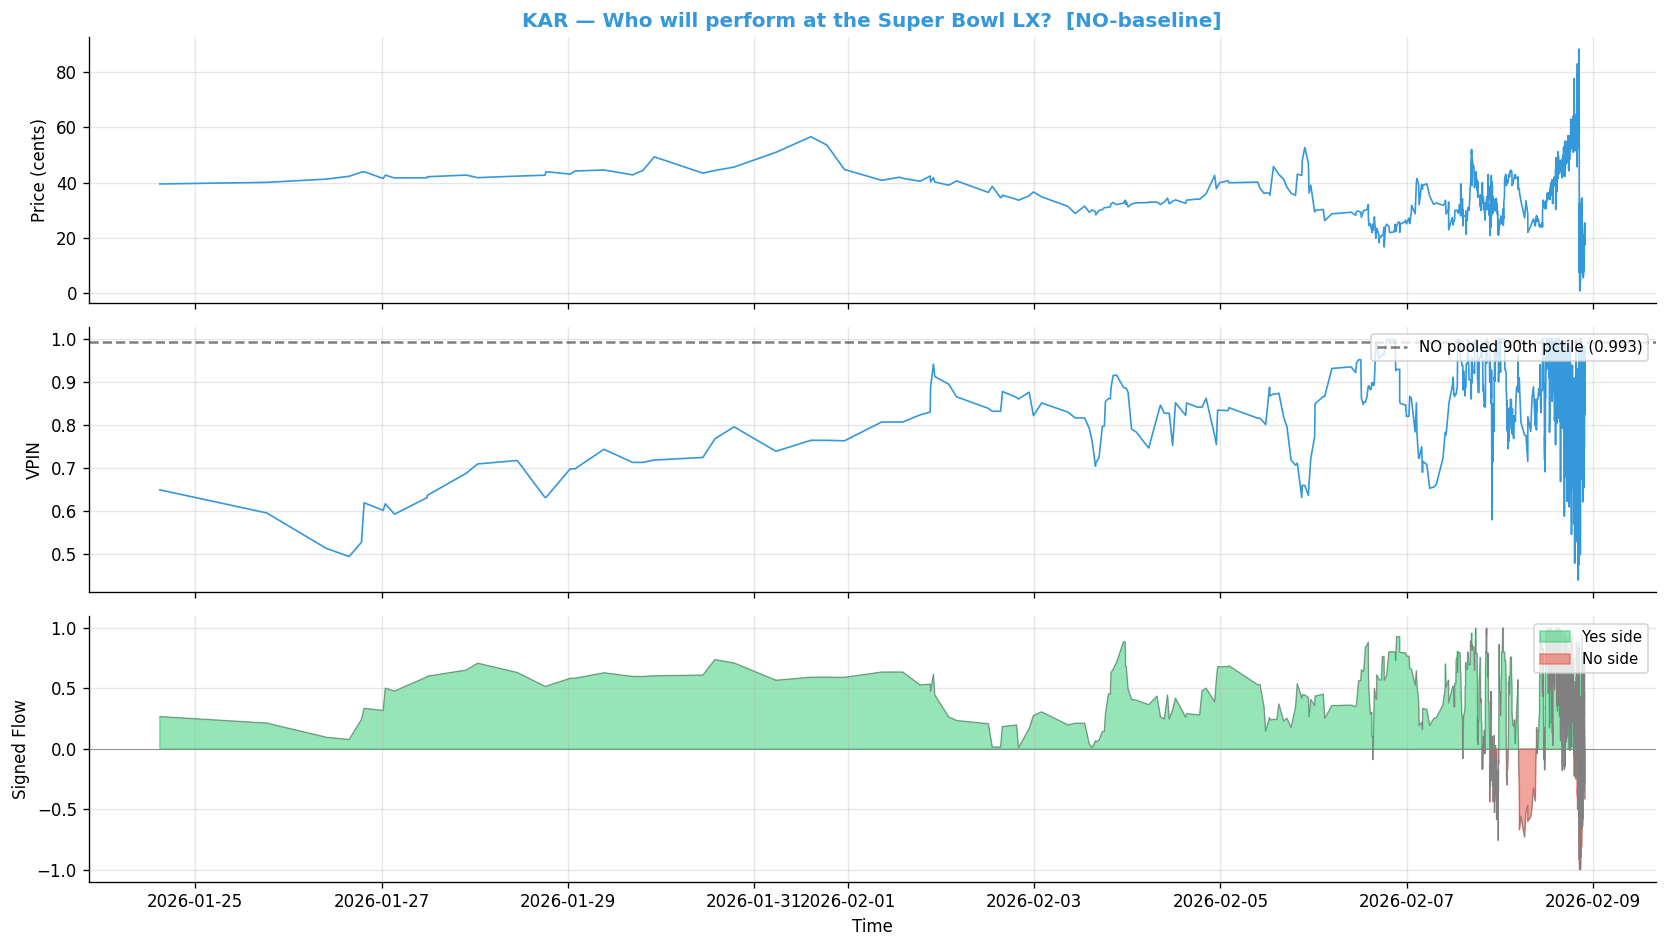

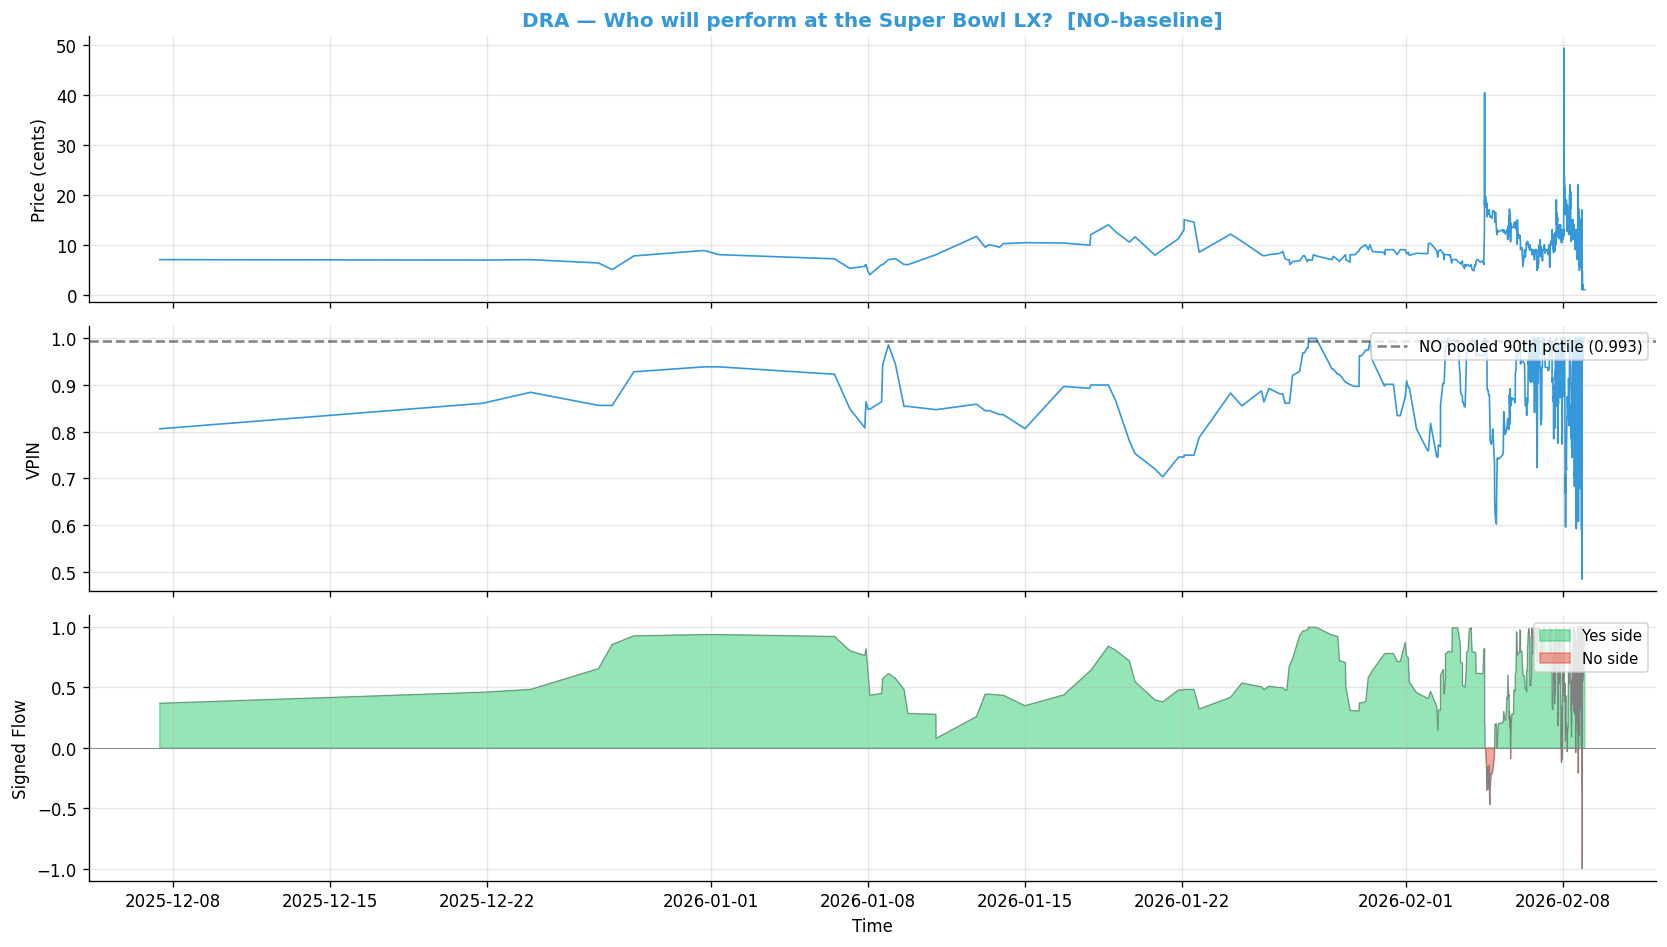

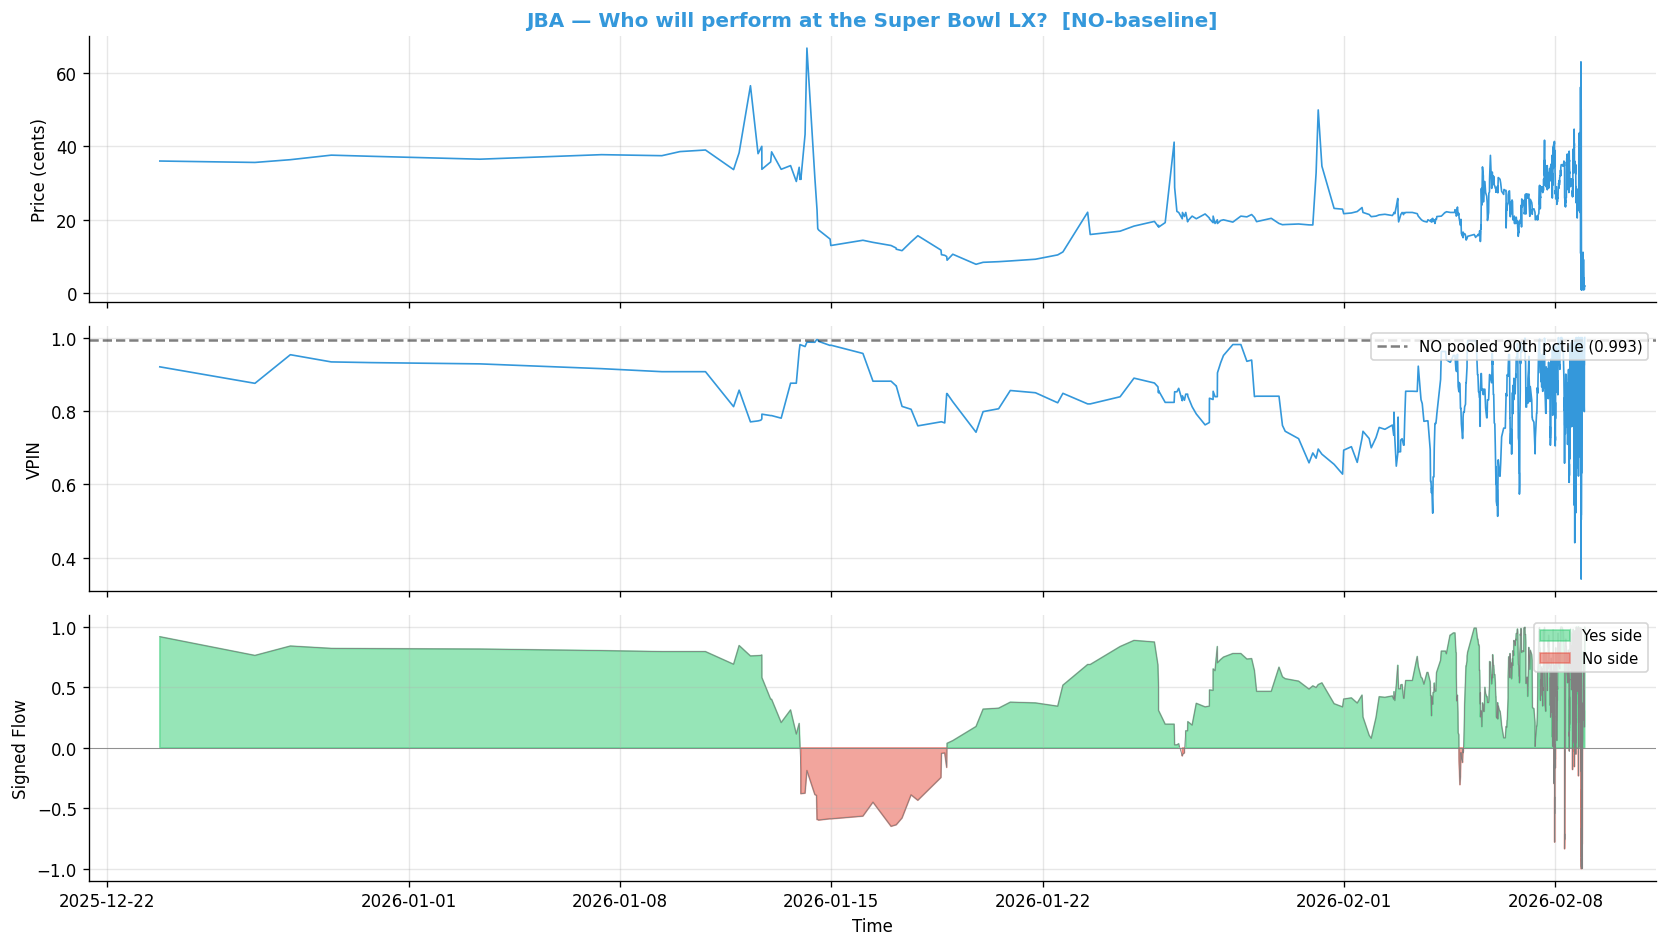

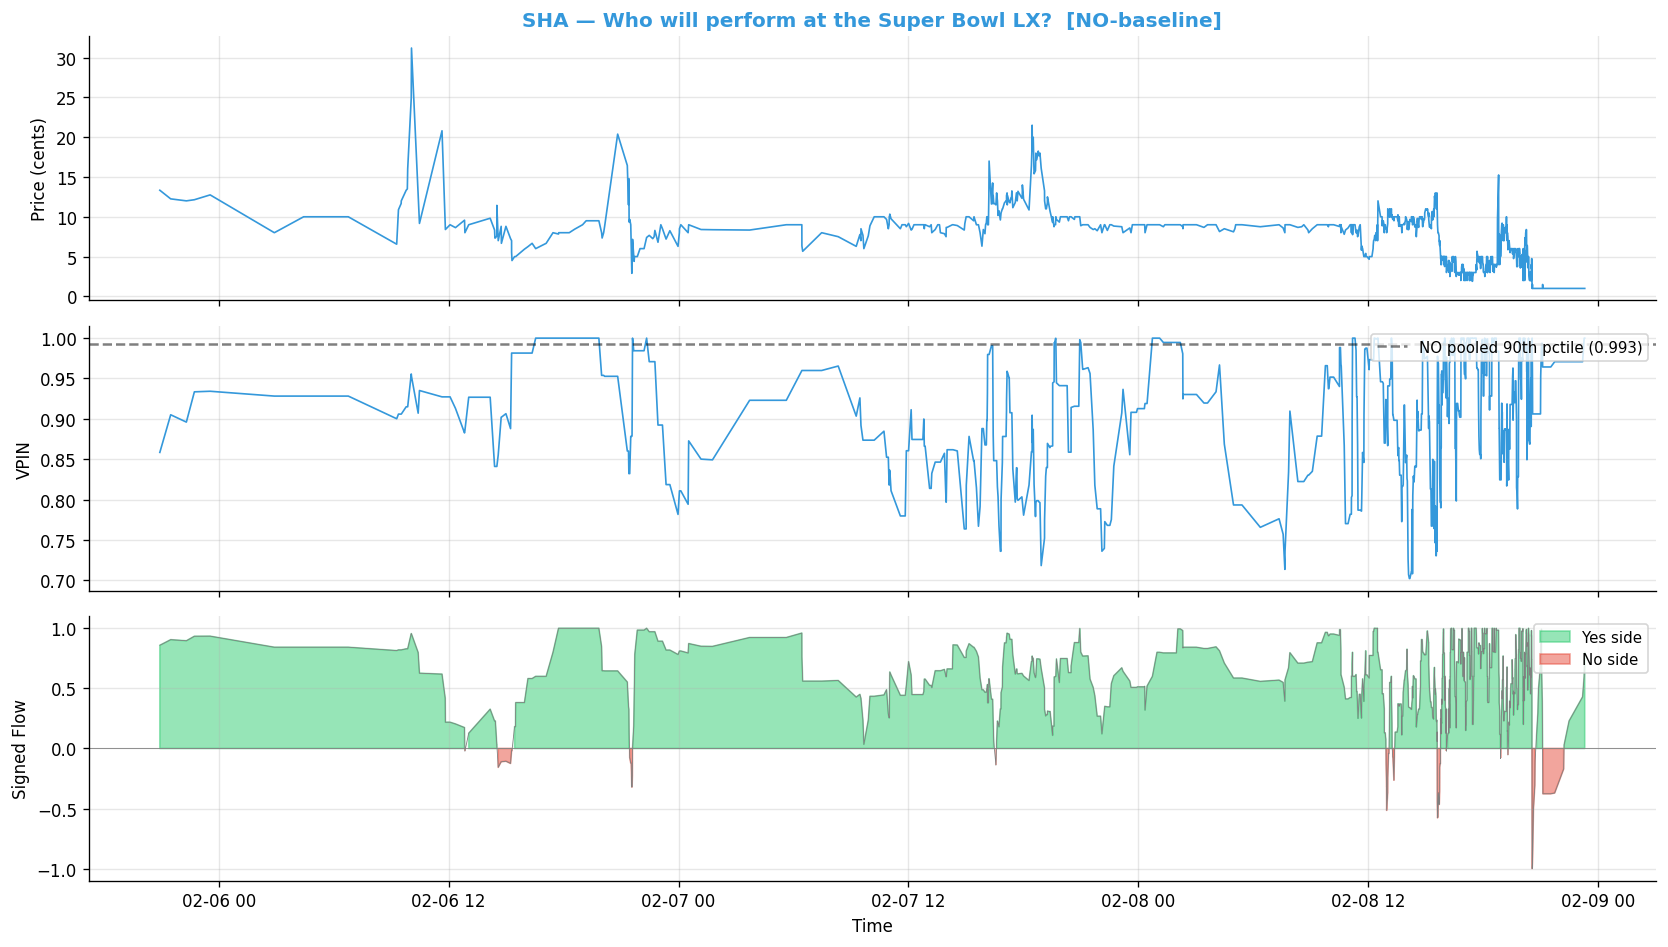

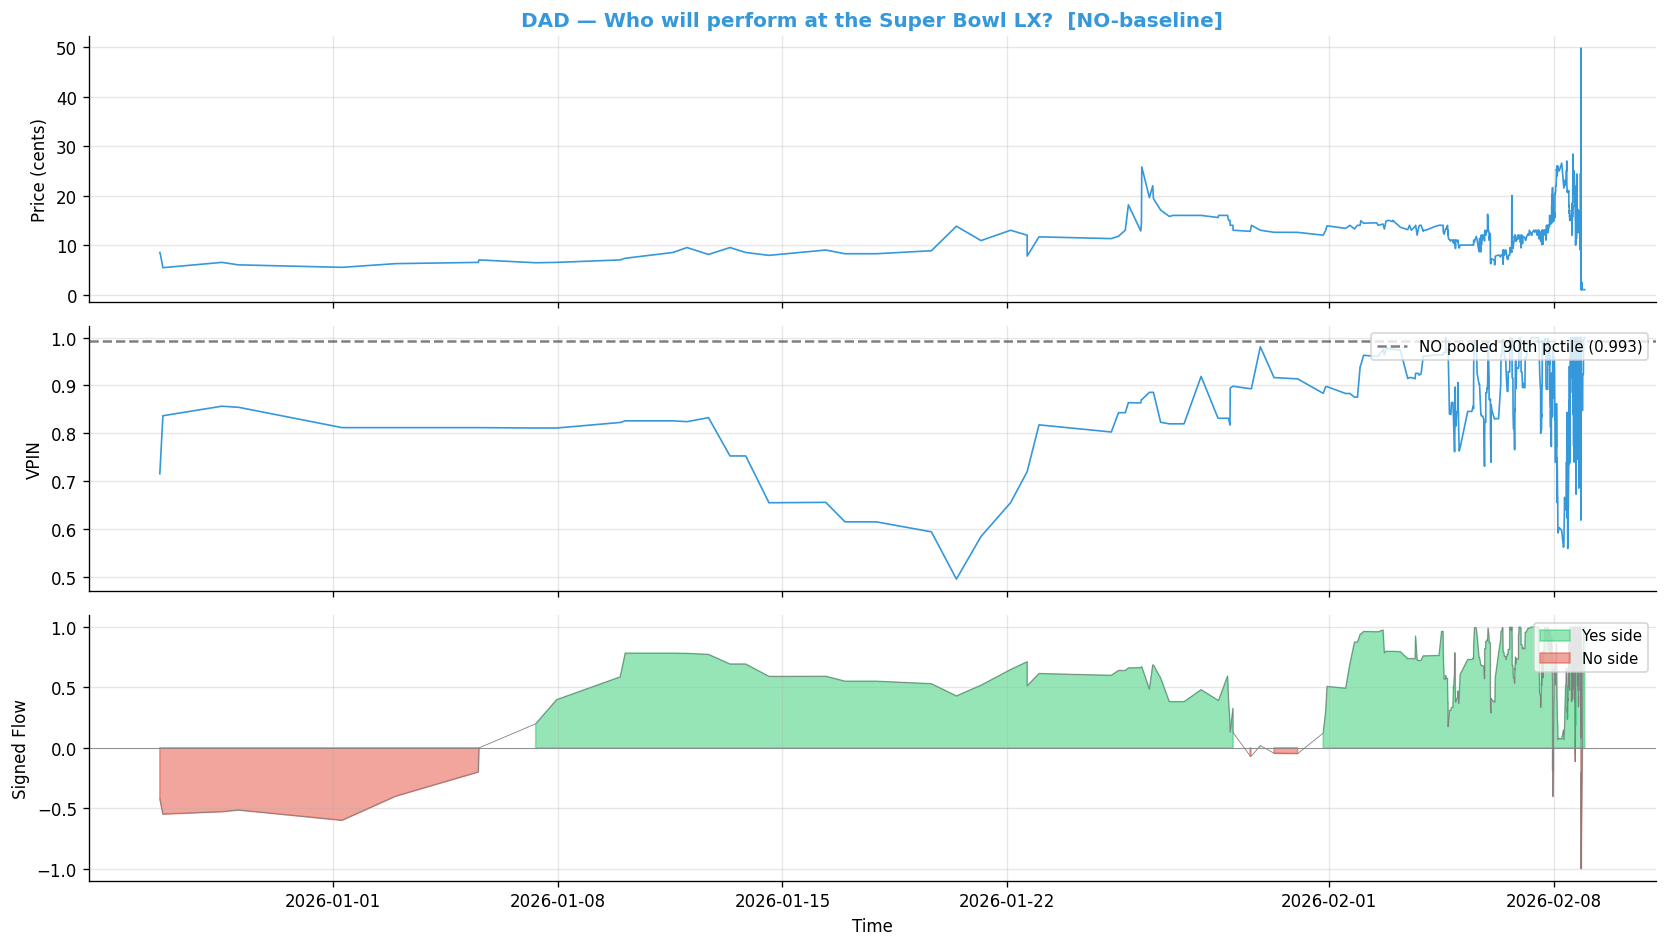

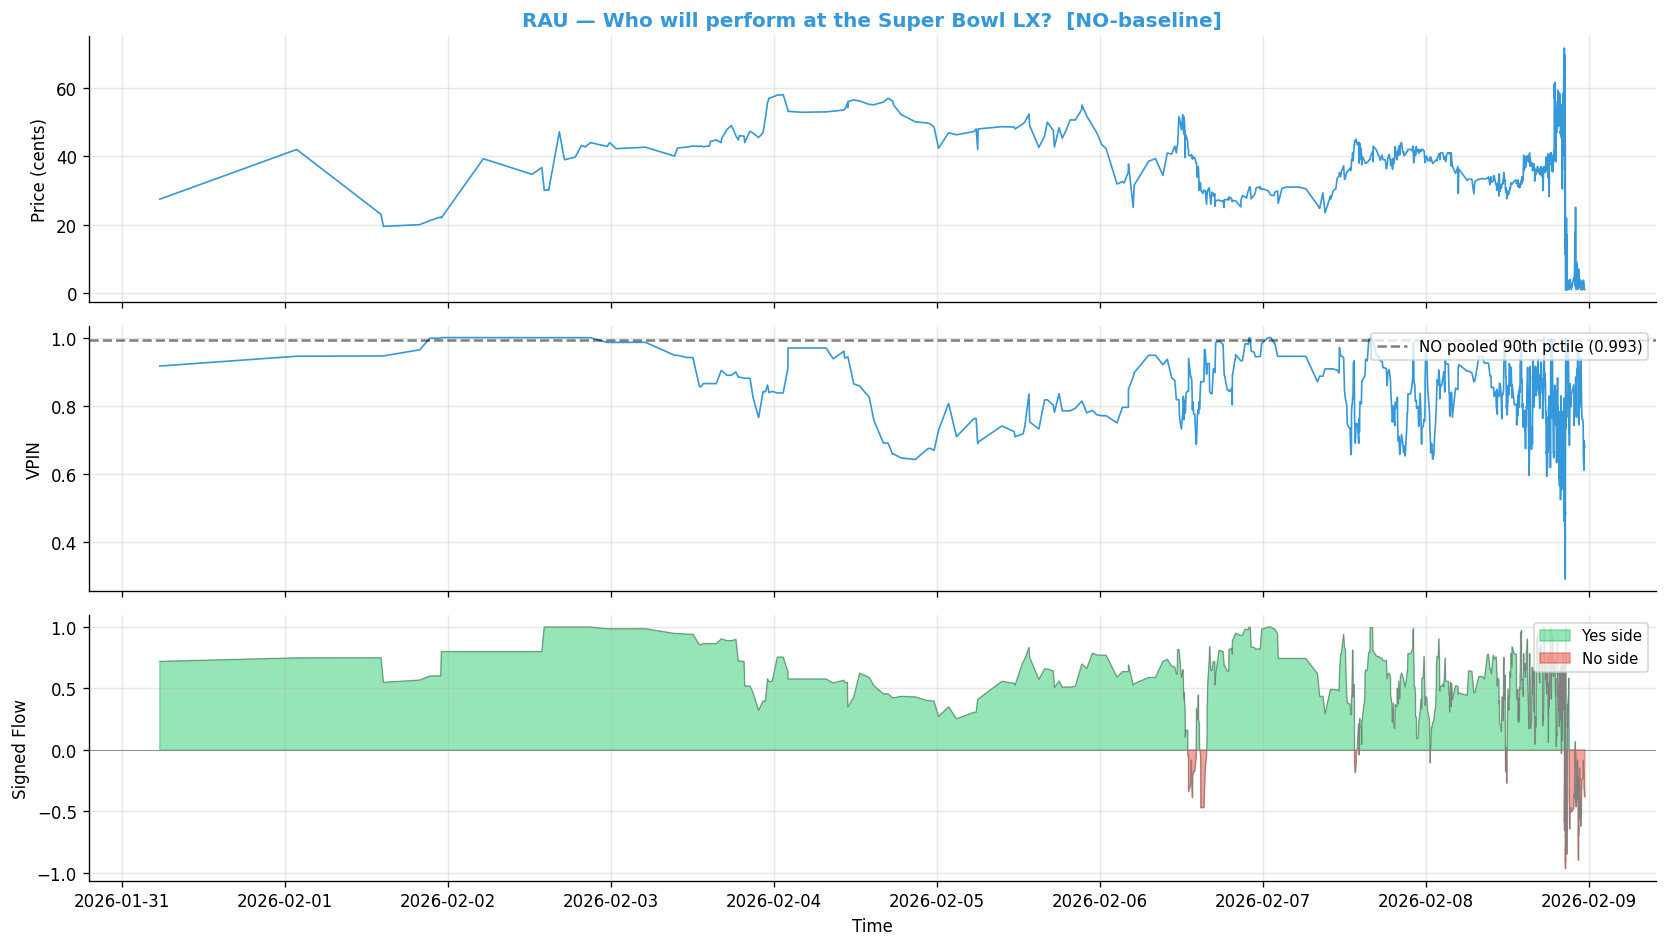

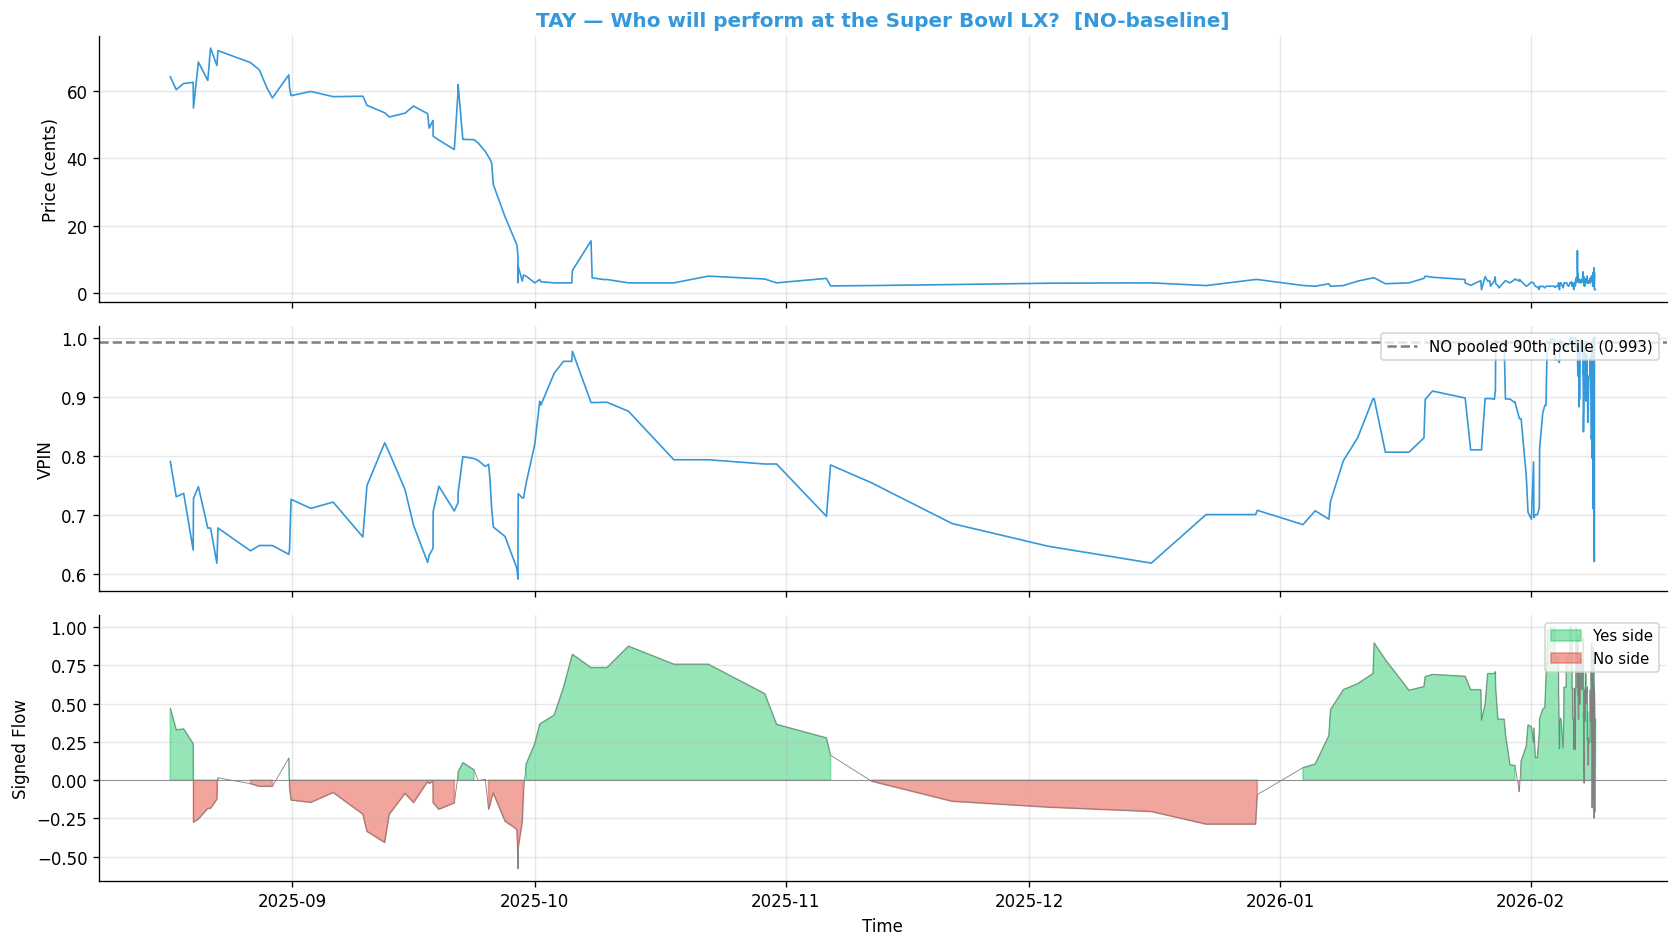

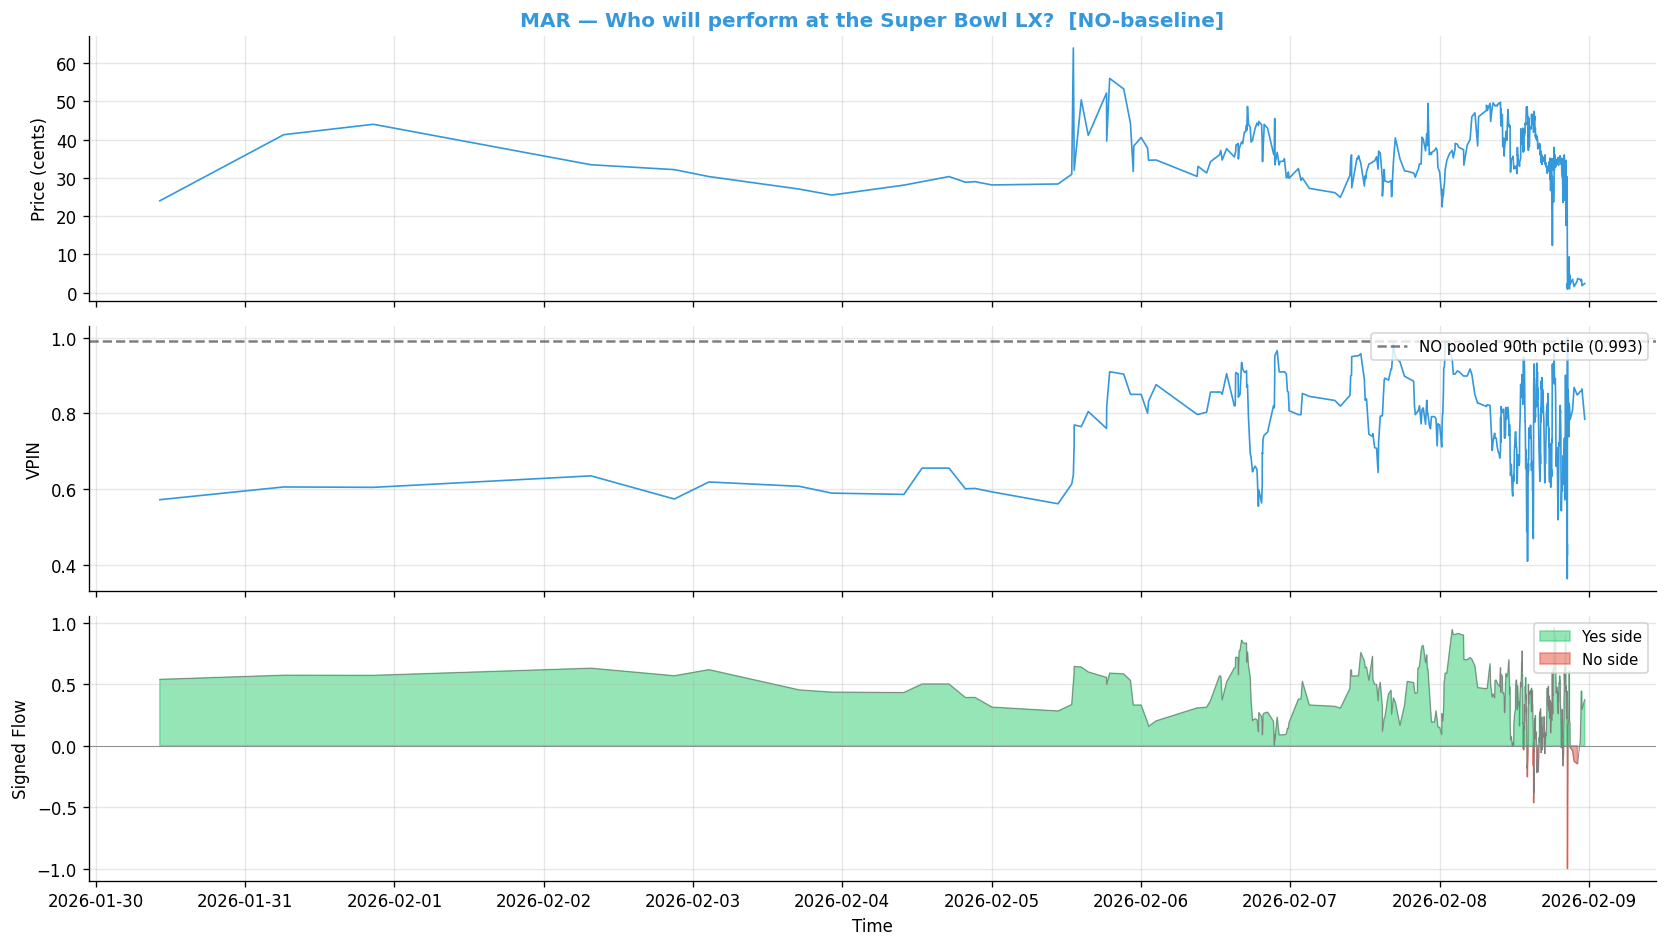

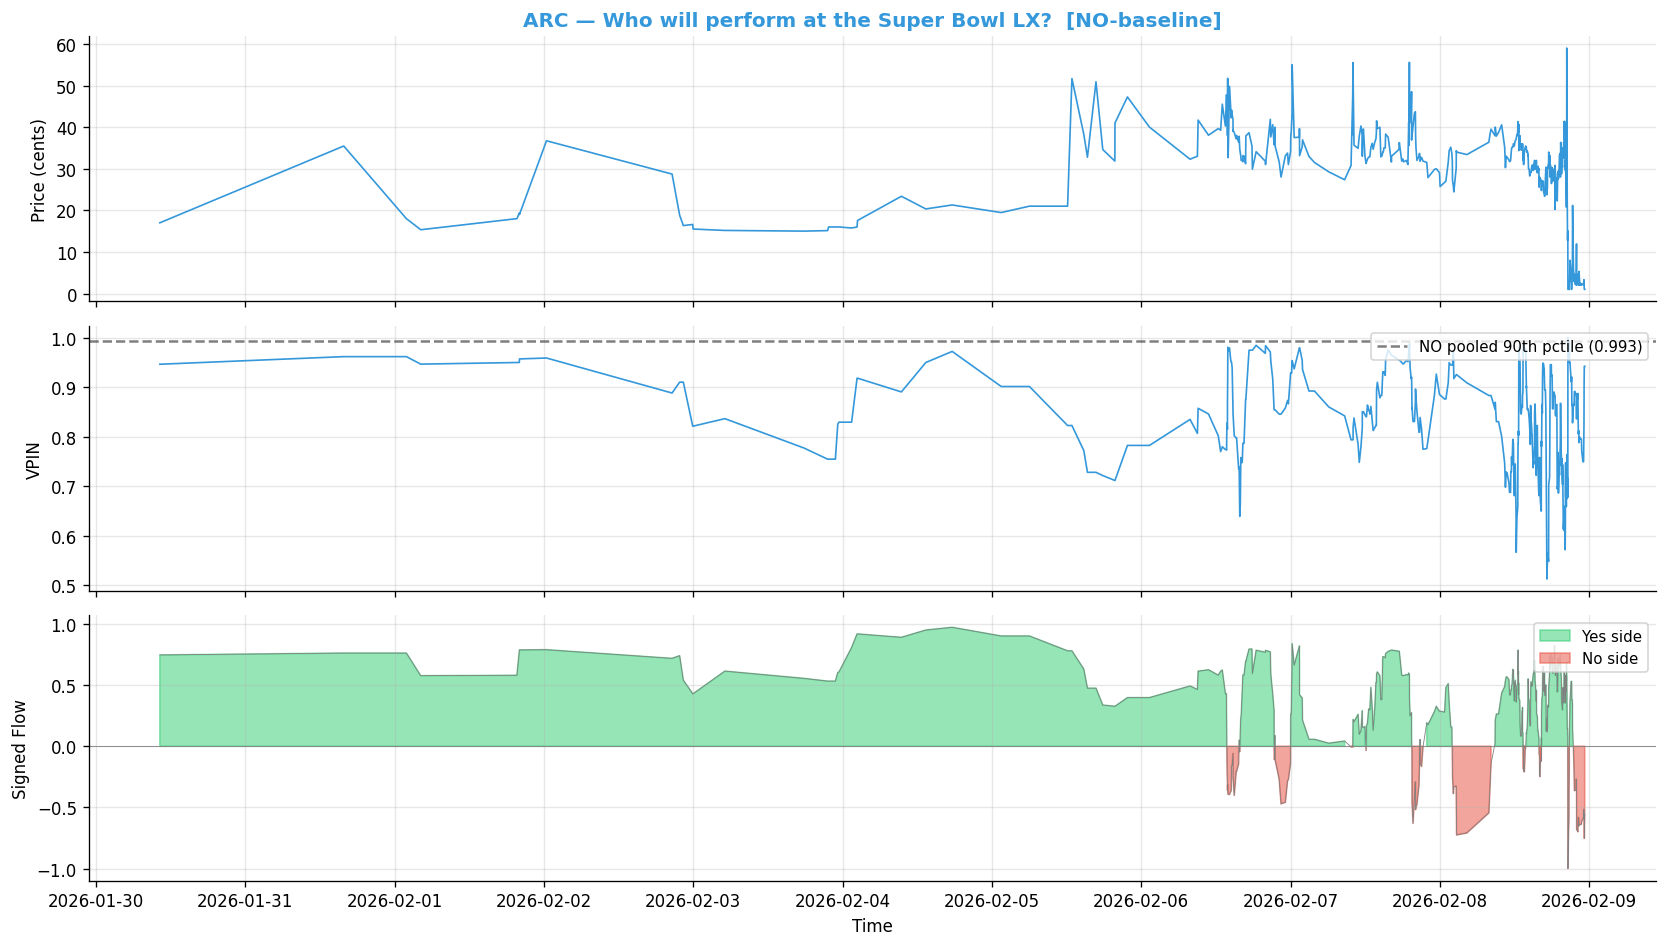

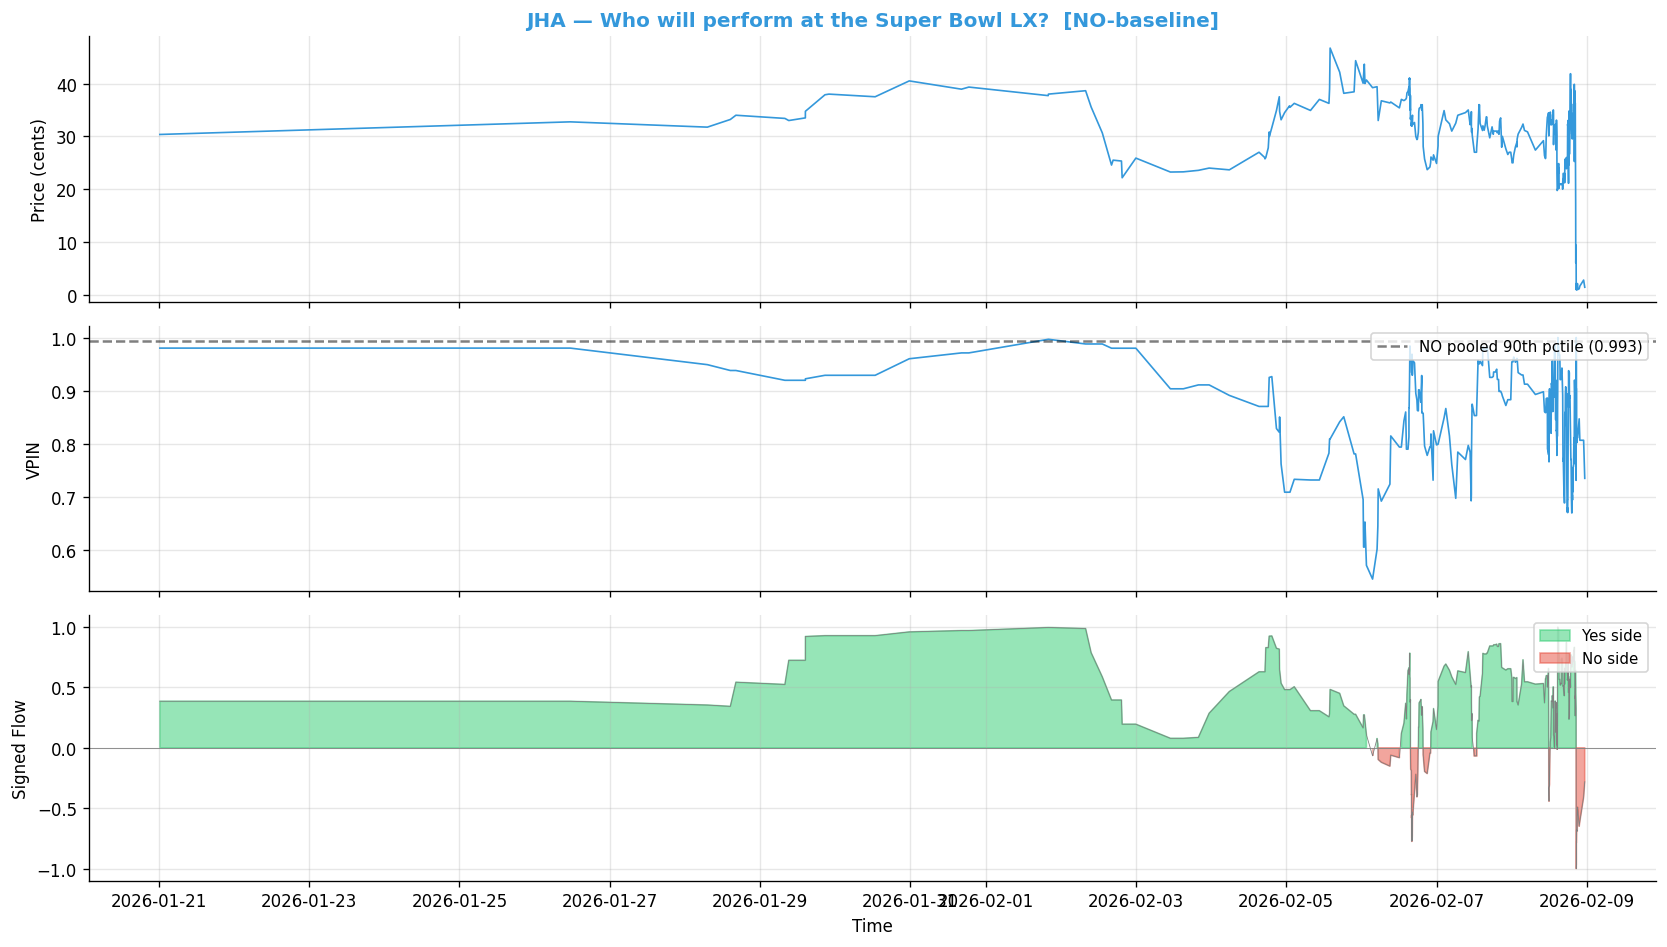

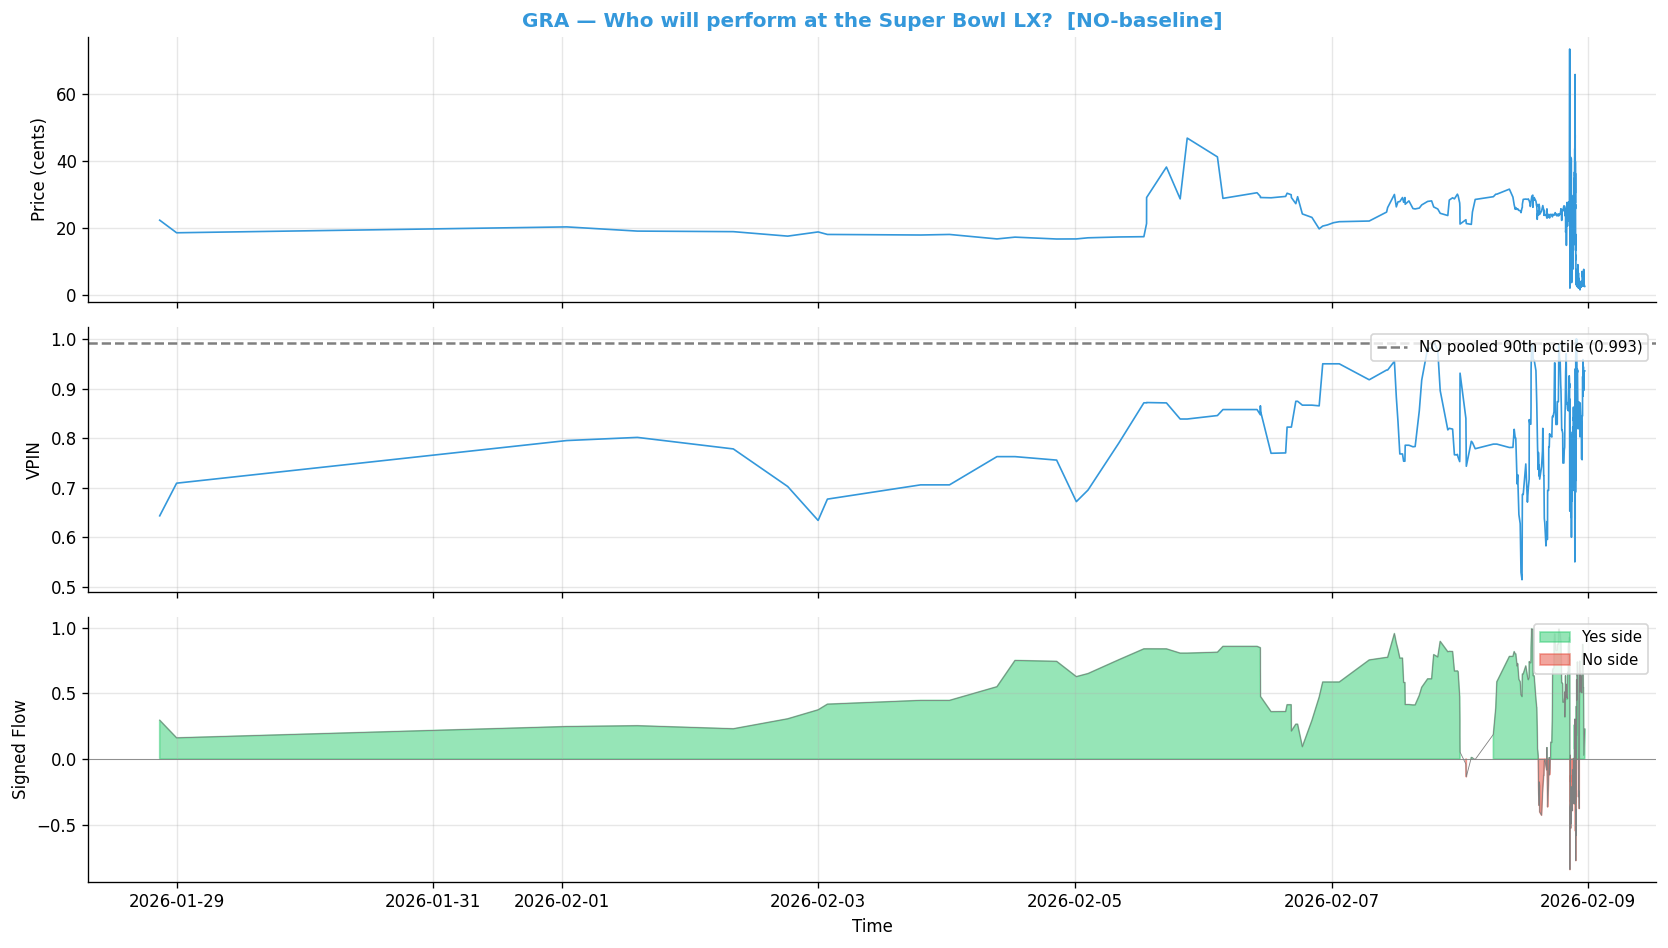

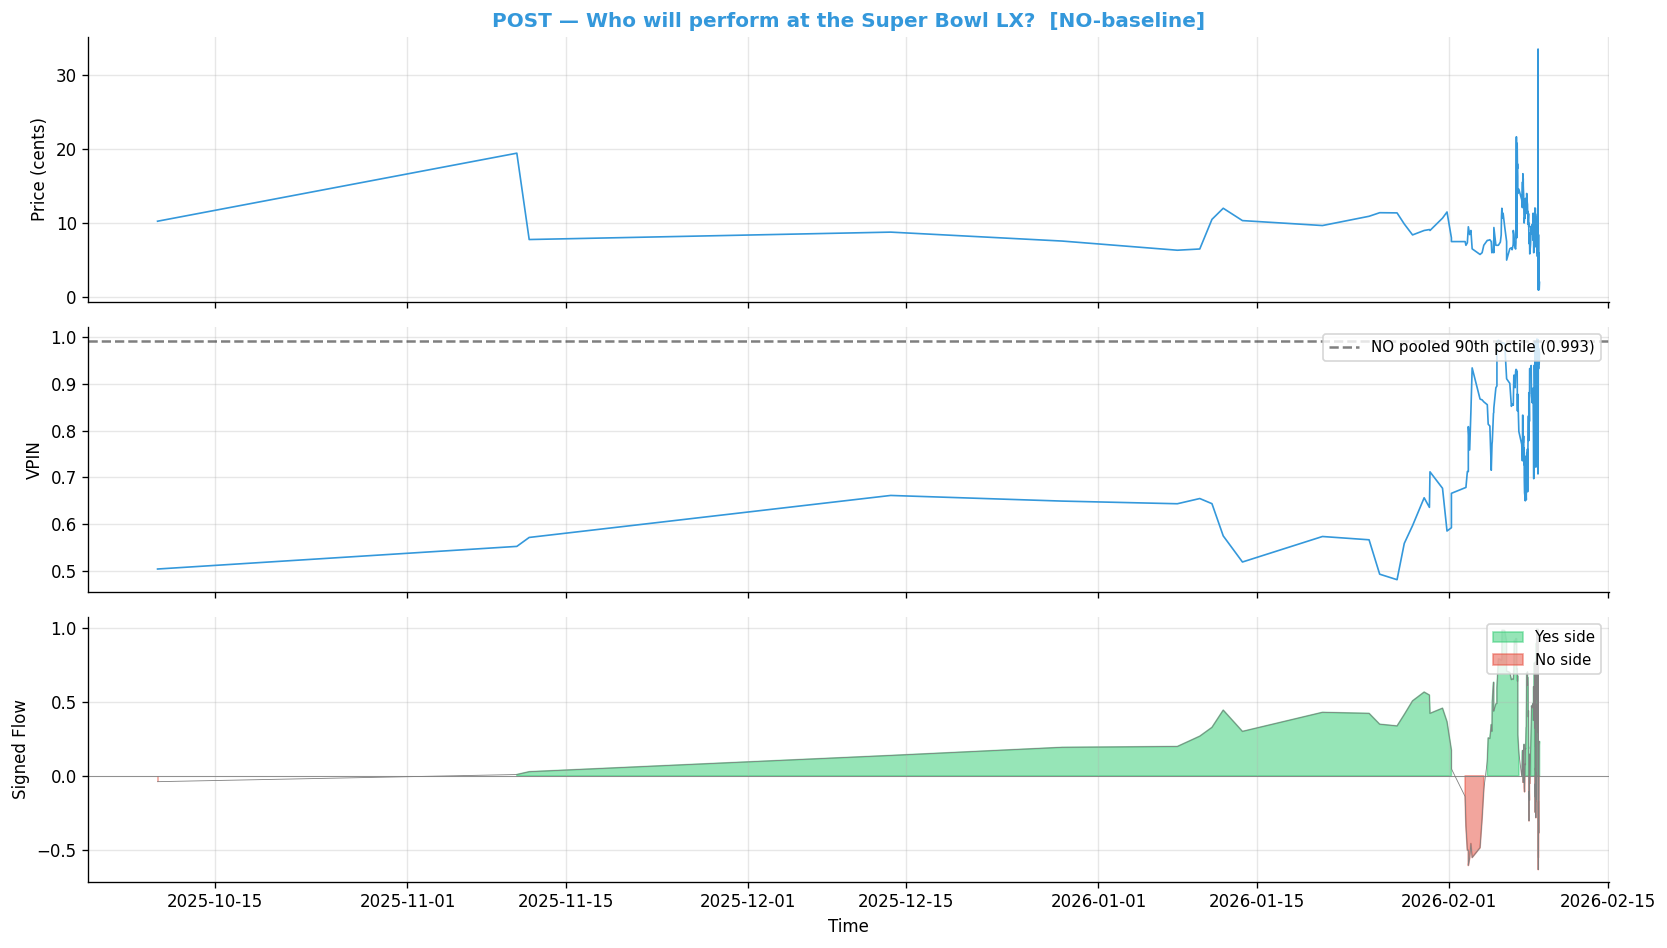

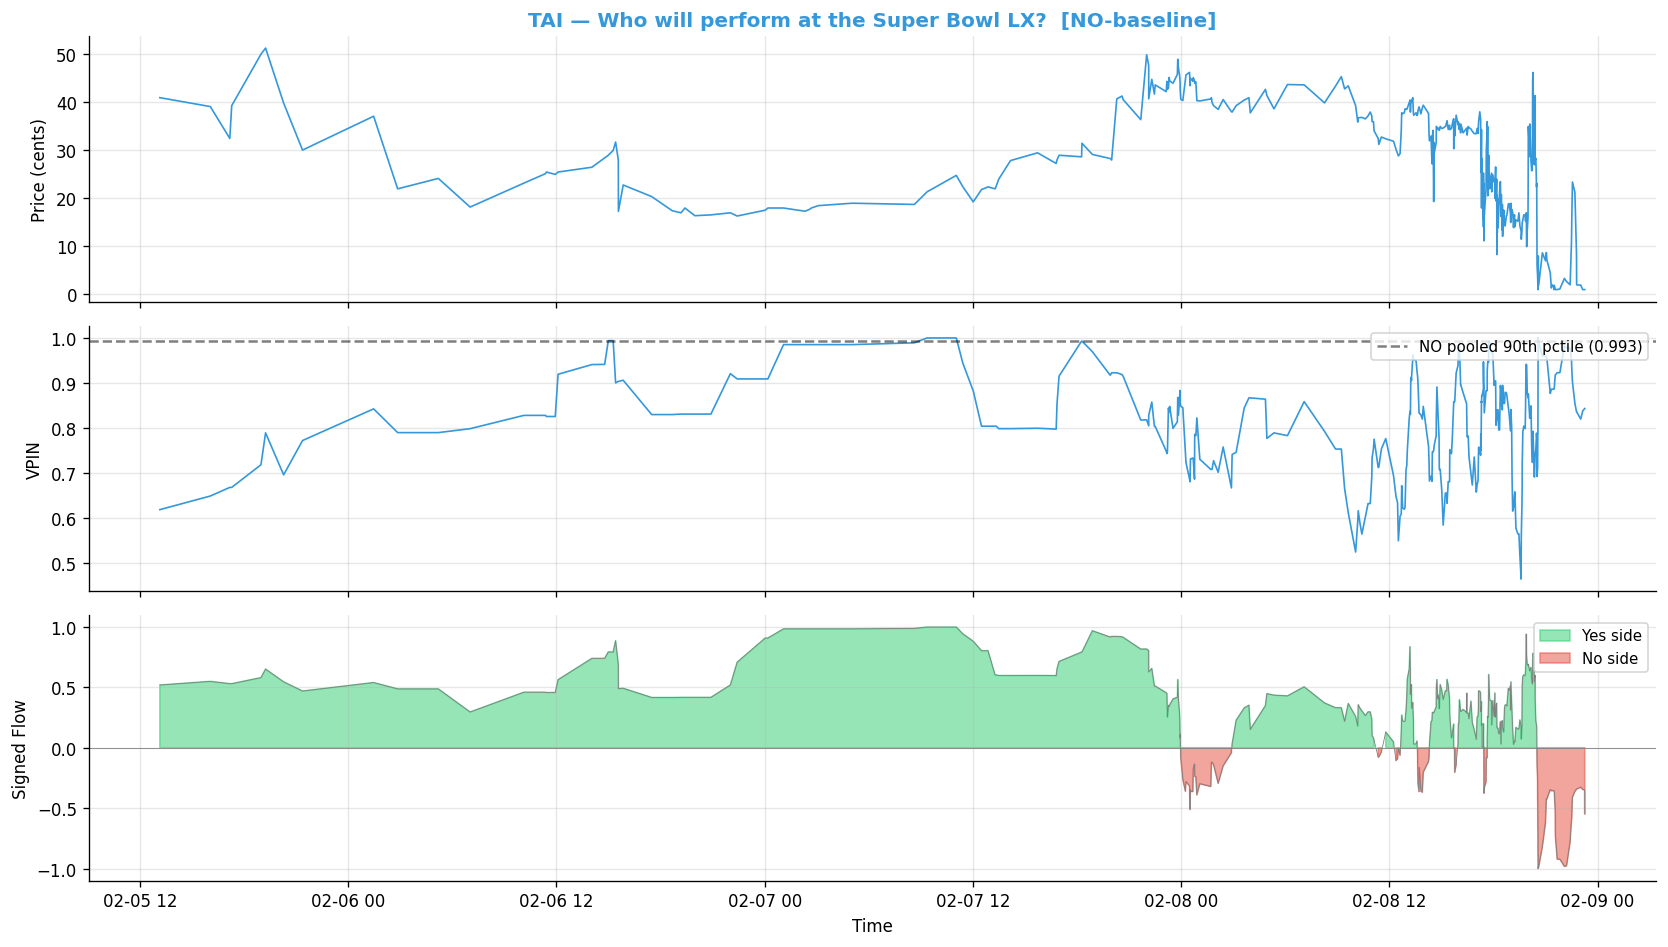

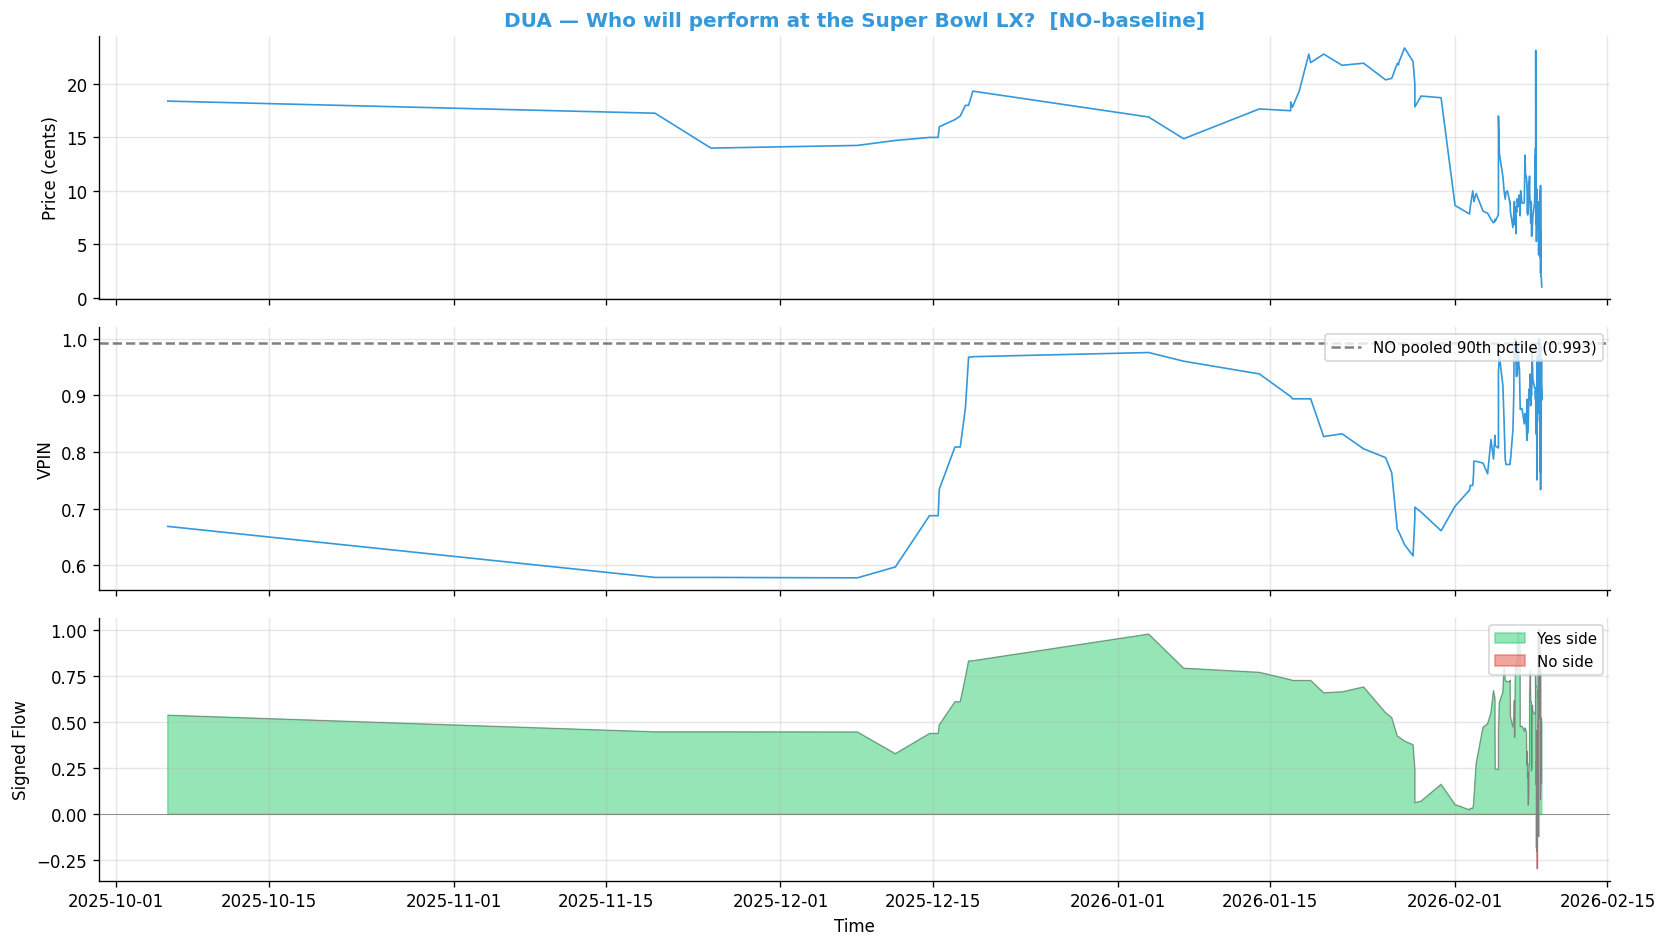

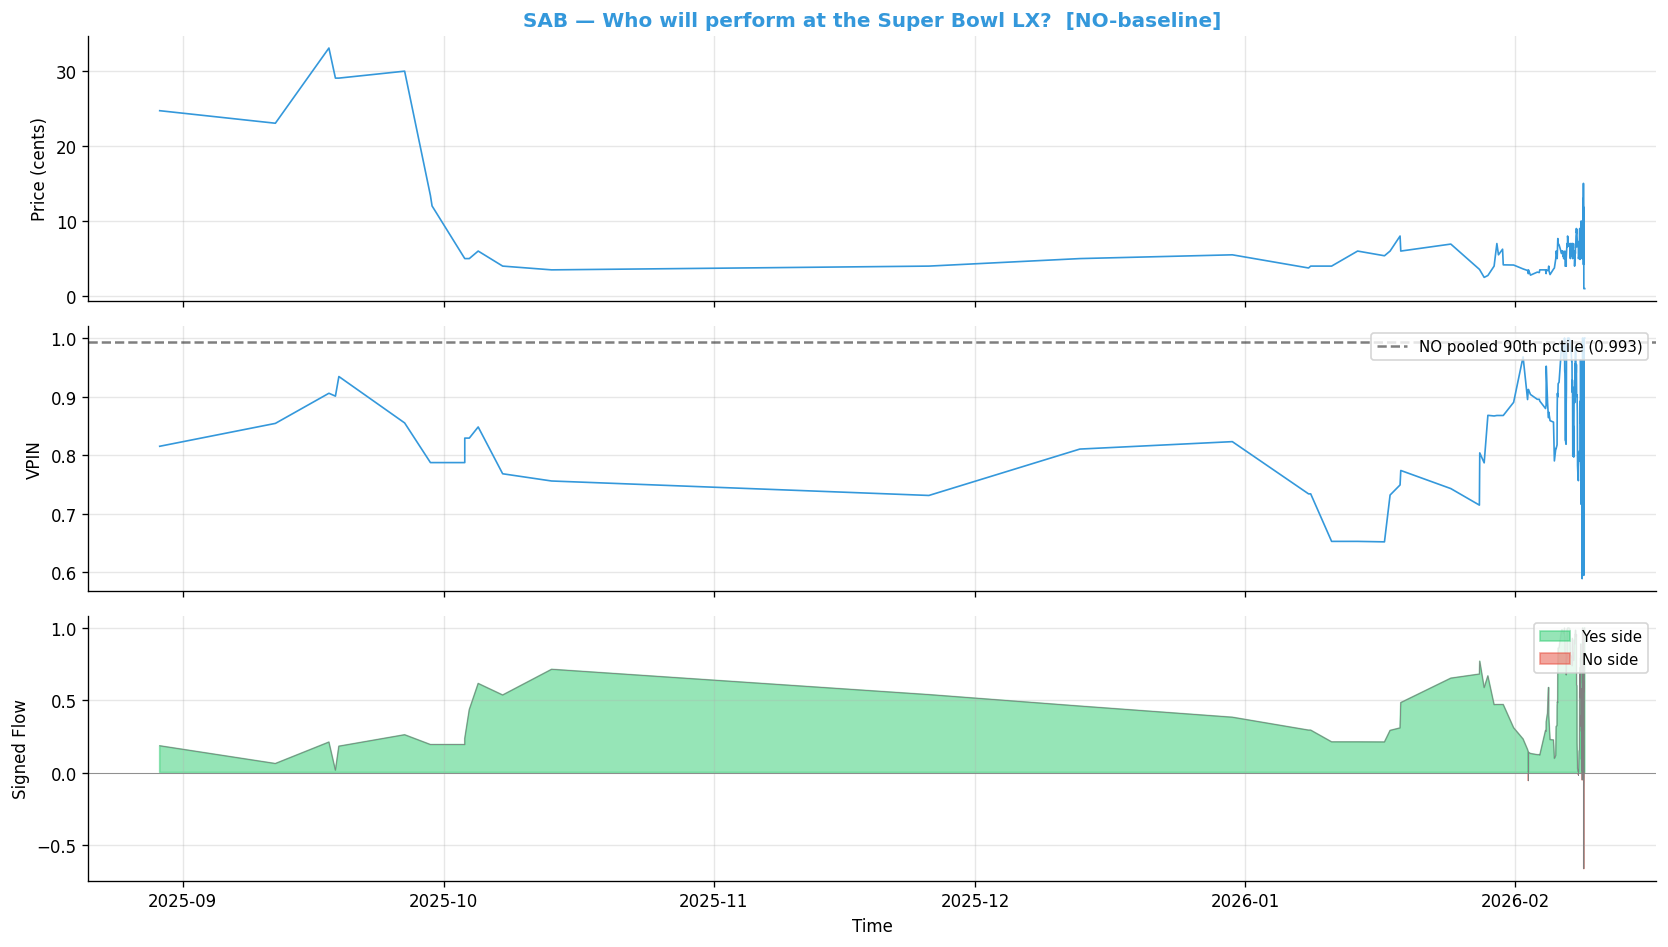

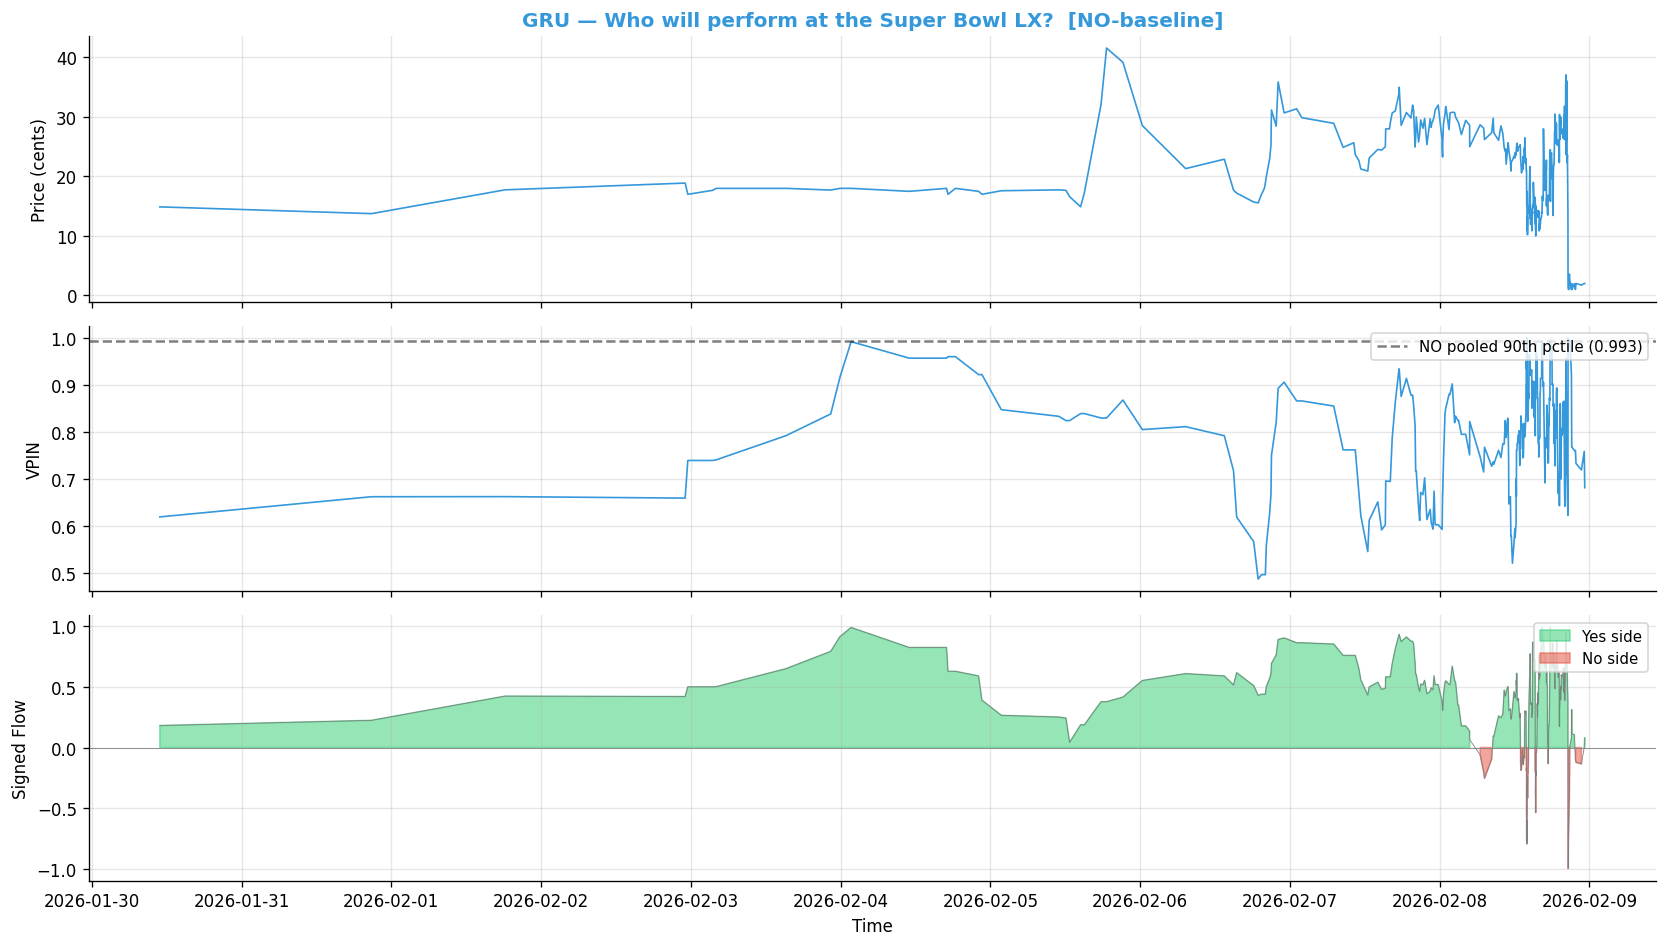

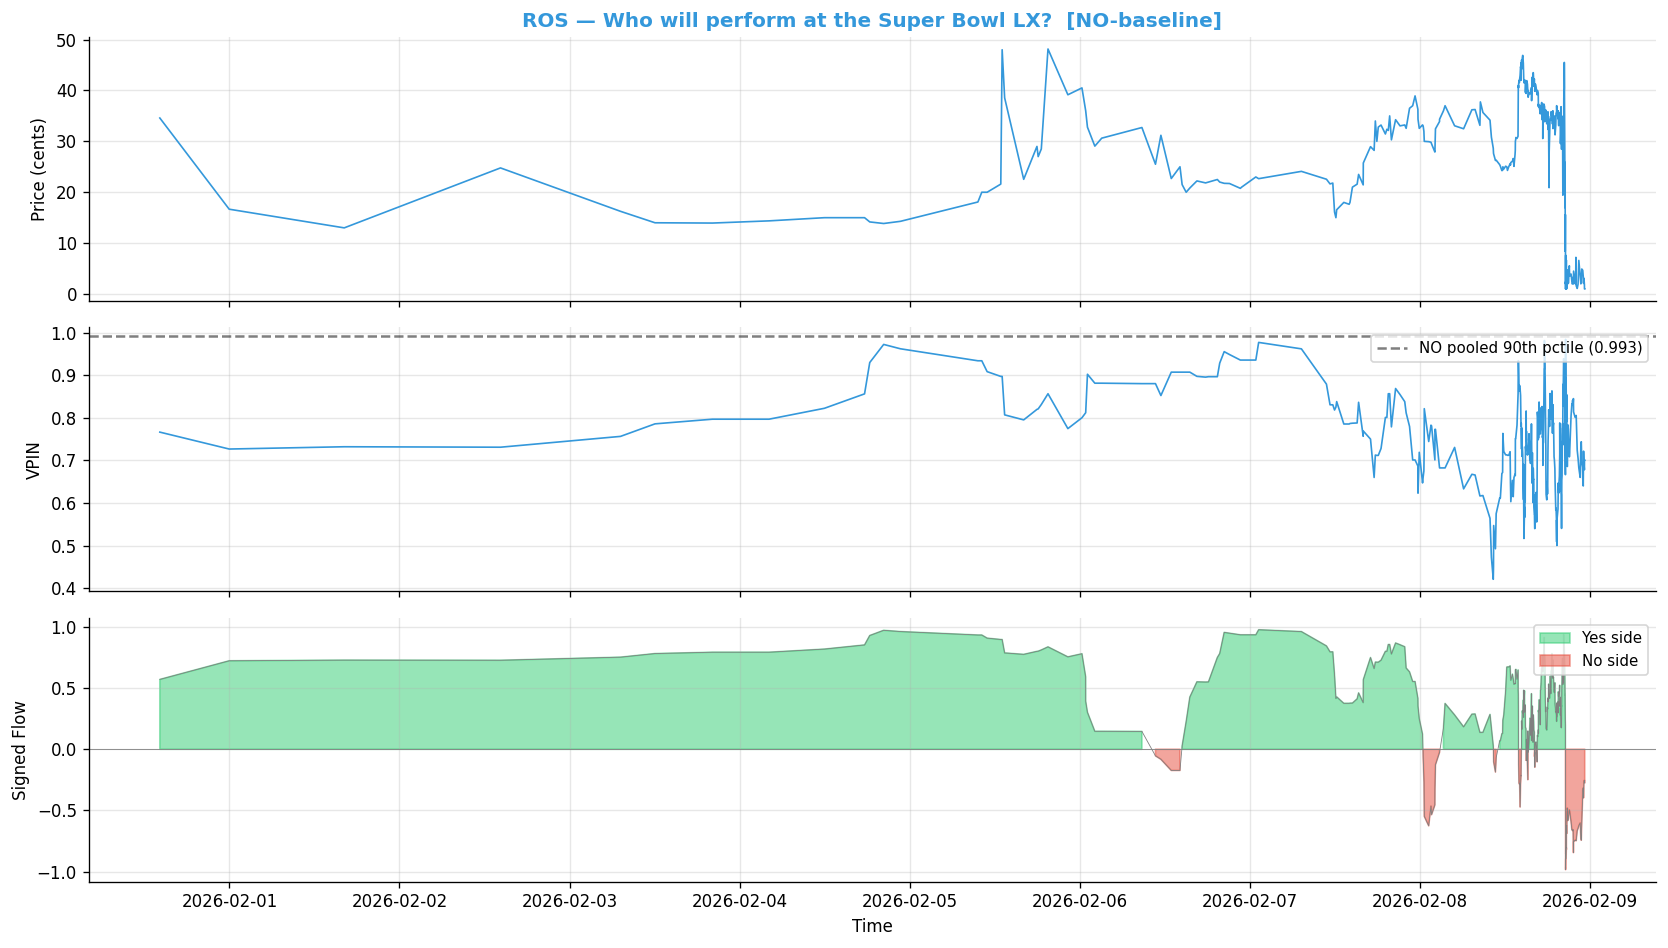

In [4]:
GROUP_COLORS = {
    "YES-surprise": "#e74c3c",
    "YES-public": "#7f8c8d",
    "NO-baseline": "#3498db",
}

for ticker in display_order:
    df = market_vpins[ticker]
    info = market_catalog[ticker]
    color = GROUP_COLORS[info["group"]]

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    time = pd.to_datetime(df["bucket_end"])

    # Price
    ax = axes[0]
    ax.plot(time, df["avg_price"], color=color, linewidth=1)
    ax.set_ylabel("Price (cents)")
    ax.set_title(
        f"{info['suffix']} \u2014 {info['title']}  [{info['group']}]",
        fontsize=12, fontweight="bold", color=color,
    )
    ax.grid(True, alpha=0.3)

    # VPIN
    ax = axes[1]
    ax.plot(time, df["vpin"], color=color, linewidth=1)
    ax.axhline(
        y=NO_P90, color="black", linestyle="--", alpha=0.5,
        label=f"NO pooled 90th pctile ({NO_P90:.3f})",
    )
    ax.set_ylabel("VPIN")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

    # Signed flow
    ax = axes[2]
    sf = df["signed_flow"].values
    ax.fill_between(time, sf, 0, where=(sf >= 0), color="#2ecc71", alpha=0.5, label="Yes side")
    ax.fill_between(time, sf, 0, where=(sf < 0), color="#e74c3c", alpha=0.5, label="No side")
    ax.plot(time, sf, color="gray", linewidth=0.5)
    ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)
    ax.set_ylabel("Signed Flow")
    ax.set_xlabel("Time")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Experiment 2: Null Distribution Comparison

Pool all NO-baseline VPIN values to create a null distribution — what VPIN looks like when nobody knows anything.

Test each YES-surprise market against this null using the two-sample Kolmogorov-Smirnov test (`alternative="greater"`). If the YES-surprise VPIN distribution is shifted right (higher), that's consistent with informed flow.

KS tests vs pooled NO-baseline null distribution:

  LAD: KS=0.0186  p=8.36e-03  *** SIGNIFICANT
  RIC: KS=0.0981  p=2.79e-21  *** SIGNIFICANT

  NO-baseline pooled: 35,621 buckets, mean VPIN=0.8786


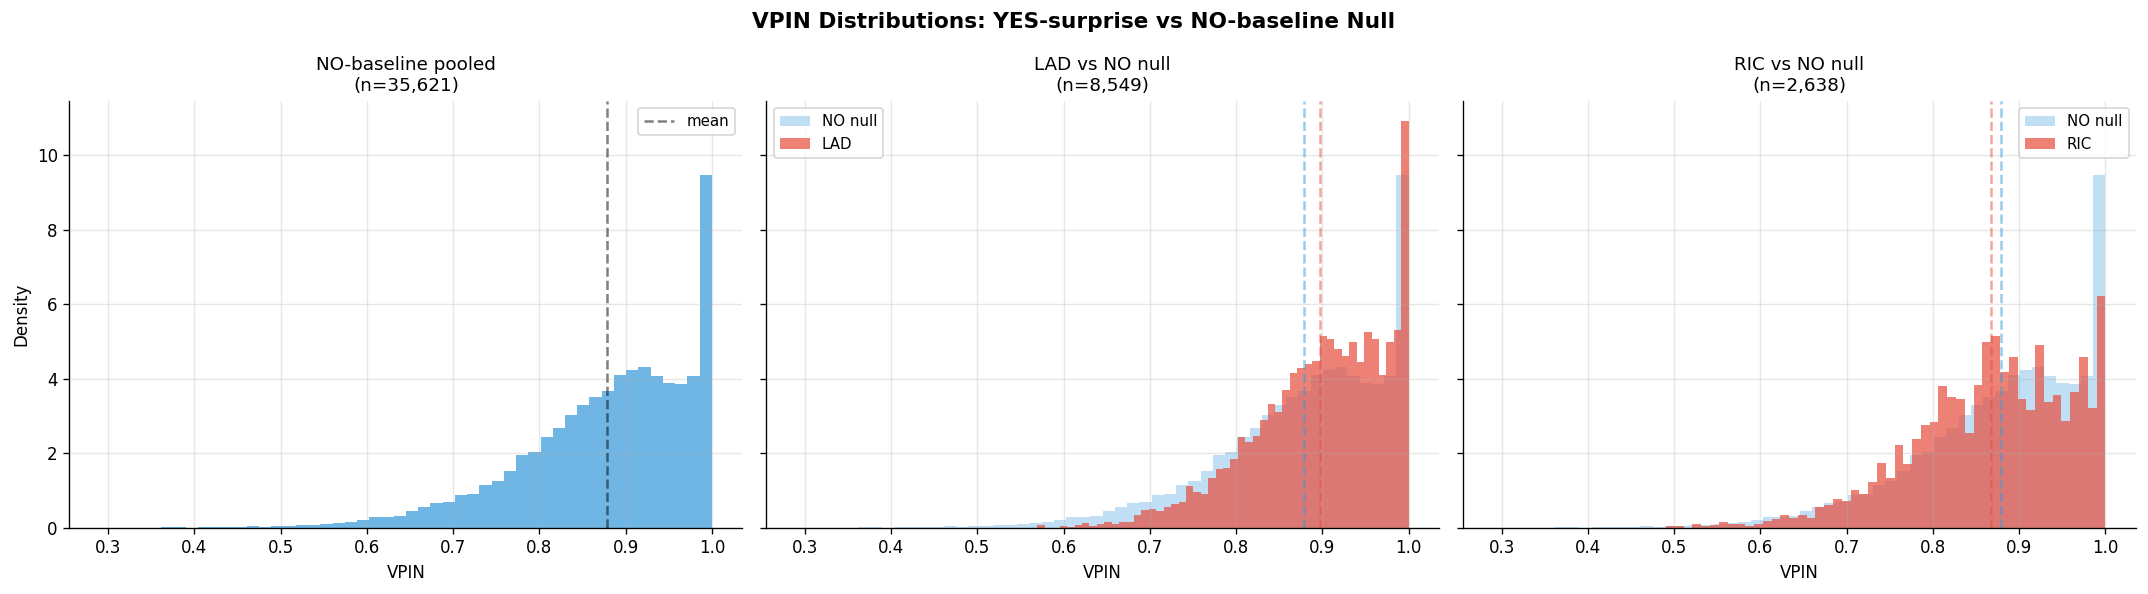

,Market,Group,Buckets,Mean VPIN,KS statistic,p-value,Significant (p<0.05)
0,LAD,YES-surprise,8549,0.8971,0.0186,8.36e-03,YES
1,RIC,YES-surprise,2638,0.8668,0.0981,2.79e-21,YES


In [5]:
# KS tests: each YES-surprise market vs pooled NO-baseline null
print("KS tests vs pooled NO-baseline null distribution:\n")
ks_results = []
for ticker in yes_surprise_tickers:
    df = market_vpins[ticker]
    info = market_catalog[ticker]
    ks_stat, p_val = stats.ks_2samp(df["vpin"].values, no_vpin_pooled, alternative="greater")
    ks_results.append({
        "Market": info["suffix"],
        "Group": info["group"],
        "Buckets": len(df),
        "Mean VPIN": f"{df['vpin'].mean():.4f}",
        "KS statistic": f"{ks_stat:.4f}",
        "p-value": f"{p_val:.2e}",
        "Significant (p<0.05)": "YES" if p_val < 0.05 else "no",
    })
    sig = "*** SIGNIFICANT" if p_val < 0.05 else ""
    print(f"  {info['suffix']}: KS={ks_stat:.4f}  p={p_val:.2e}  {sig}")

print(f"\n  NO-baseline pooled: {len(no_vpin_pooled):,} buckets, mean VPIN={no_vpin_pooled.mean():.4f}")

# Histogram overlays
n_panels = len(yes_surprise_tickers) + 1
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), sharey=True)
if n_panels == 1:
    axes = [axes]

# NO-baseline pooled
ax = axes[0]
ax.hist(no_vpin_pooled, bins=50, alpha=0.7, color="#3498db", density=True)
ax.set_title(f"NO-baseline pooled\n(n={len(no_vpin_pooled):,})", fontsize=11)
ax.set_xlabel("VPIN")
ax.set_ylabel("Density")
ax.axvline(x=np.mean(no_vpin_pooled), color="black", linestyle="--", alpha=0.5, label="mean")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# YES-surprise markets
for i, ticker in enumerate(yes_surprise_tickers):
    ax = axes[i + 1]
    df = market_vpins[ticker]
    info = market_catalog[ticker]
    ax.hist(no_vpin_pooled, bins=50, alpha=0.3, color="#3498db", density=True, label="NO null")
    ax.hist(df["vpin"].values, bins=50, alpha=0.7, color="#e74c3c", density=True, label=info["suffix"])
    ax.set_title(f"{info['suffix']} vs NO null\n(n={len(df):,})", fontsize=11)
    ax.set_xlabel("VPIN")
    ax.axvline(x=df["vpin"].mean(), color="#e74c3c", linestyle="--", alpha=0.5)
    ax.axvline(x=no_vpin_pooled.mean(), color="#3498db", linestyle="--", alpha=0.5)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("VPIN Distributions: YES-surprise vs NO-baseline Null", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

pd.DataFrame(ks_results)

## Experiment 3: Spike Catalog + Directional Accuracy

**The core test.** When VPIN spikes above the NO-baseline 90th percentile:

1. How often does the direction of `signed_flow` correctly predict the next price move? (**Hit rate**)
2. Is this hit rate higher for YES-surprise markets than NO-baseline?

If YES-surprise markets show a hit rate well above 50% while NO-baseline markets hover around 50%, then VPIN + signed_flow contains directional information when insiders are active.

The spike threshold is the pooled NO 90th percentile — the same ruler for every market.

In [6]:
FORWARD_BUCKETS = [5, 10, 20]
spike_threshold = NO_P90


def compute_directional_accuracy(df, threshold, forward_k):
    """Hit rate: does signed_flow at VPIN spikes predict the price move k buckets later?"""
    spike_mask = df["vpin"] > threshold
    spike_indices = df.index[spike_mask].values
    if len(spike_indices) == 0:
        return float("nan"), 0

    price = df["avg_price"].values
    signed = df["signed_flow"].values
    hits, total = 0, 0
    for idx in spike_indices:
        future = idx + forward_k
        if future >= len(price):
            continue
        delta = price[future] - price[idx]
        if delta == 0:
            continue
        if np.sign(signed[idx]) == np.sign(delta):
            hits += 1
        total += 1

    if total == 0:
        return float("nan"), 0
    return hits / total, total


print(f"Spike threshold (NO pooled 90th pctile): {spike_threshold:.4f}\n")

rows = []
for ticker in display_order:
    df = market_vpins[ticker]
    info = market_catalog[ticker]
    n_spikes = int((df["vpin"] > spike_threshold).sum())

    row = {
        "Market": info["suffix"],
        "Group": info["group"],
        "Buckets": len(df),
        "Spikes": n_spikes,
        "Spike %": f"{100 * n_spikes / len(df):.1f}%",
    }

    for k in FORWARD_BUCKETS:
        hr, n = compute_directional_accuracy(df, spike_threshold, k)
        row[f"Hit (k={k})"] = f"{hr:.1%}" if not np.isnan(hr) else "N/A"
        row[f"n={k}"] = n

    # Average aligned move at k=10
    spike_mask = df["vpin"] > spike_threshold
    spike_idx = df.index[spike_mask].values
    price = df["avg_price"].values
    aligned_moves = []
    for idx in spike_idx:
        if idx + 10 >= len(price):
            continue
        delta = price[idx + 10] - price[idx]
        aligned_moves.append(delta * np.sign(df["signed_flow"].values[idx]))
    row["Avg aligned (k=10)"] = f"{np.mean(aligned_moves):+.2f}" if aligned_moves else "N/A"

    rows.append(row)

accuracy_df = pd.DataFrame(rows)
display(accuracy_df)

# Group-level summary
print("\n--- Group averages (markets with >= 5 valid spikes) ---")
for group in ["YES-surprise", "NO-baseline", "YES-public"]:
    group_tickers = [t for t in market_vpins if market_catalog[t]["group"] == group]
    if not group_tickers:
        continue
    print(f"\n  {group}:")
    for k in FORWARD_BUCKETS:
        rates = []
        for t in group_tickers:
            hr, n = compute_directional_accuracy(market_vpins[t], spike_threshold, k)
            if not np.isnan(hr) and n >= 5:
                rates.append(hr)
        if rates:
            print(f"    k={k:2d}: mean hit rate = {np.mean(rates):.1%}  (n={len(rates)} markets)")

Spike threshold (NO pooled 90th pctile): 0.9928



,Market,Group,Buckets,Spikes,Spike %,Hit (k=5),n=5,Hit (k=10),n=10,Hit (k=20),n=20,Avg aligned (k=10)
0,LAD,YES-surprise,8549,744,8.7%,47.5%,465,52.1%,505,56.1%,512,-0.05
1,RIC,YES-surprise,2638,145,5.5%,49.3%,73,65.1%,83,70.7%,82,+0.54
2,BAD,YES-public,207,9,4.3%,66.7%,9,28.6%,7,37.5%,8,-1.64
3,TRA,NO-baseline,18473,2289,12.4%,47.9%,1439,50.3%,1579,52.2%,1731,+0.03
4,KAR,NO-baseline,3848,210,5.5%,60.0%,160,64.6%,178,55.9%,202,+1.33
5,DRA,NO-baseline,2374,299,12.6%,44.6%,224,36.2%,235,51.6%,250,-1.03
6,JBA,NO-baseline,2432,87,3.6%,50.8%,65,52.8%,72,41.0%,78,+0.80
7,SHA,NO-baseline,1160,272,23.4%,51.9%,162,54.0%,187,51.0%,204,+0.30
8,DAD,NO-baseline,1280,208,16.2%,47.8%,161,42.7%,164,40.6%,170,-0.13
9,RAU,NO-baseline,1264,33,2.6%,53.1%,32,60.0%,30,61.3%,31,+3.72



--- Group averages (markets with >= 5 valid spikes) ---

  YES-surprise:
    k= 5: mean hit rate = 48.4%  (n=2 markets)
    k=10: mean hit rate = 58.6%  (n=2 markets)
    k=20: mean hit rate = 63.4%  (n=2 markets)

  NO-baseline:
    k= 5: mean hit rate = 48.8%  (n=15 markets)
    k=10: mean hit rate = 53.7%  (n=15 markets)
    k=20: mean hit rate = 53.9%  (n=15 markets)

  YES-public:
    k= 5: mean hit rate = 66.7%  (n=1 markets)
    k=10: mean hit rate = 28.6%  (n=1 markets)
    k=20: mean hit rate = 37.5%  (n=1 markets)


## Experiment 4: Lead-Lag Cross-Correlation

Does VPIN *lead* price changes, or merely coincide?

Cross-correlation between VPIN and |delta-price| at various lags:
- **Peak at positive lag:** VPIN today predicts future price volatility → information leakage
- **Peak at lag 0:** simultaneous → could be mechanical
- **Peak at negative lag:** price changes predict VPIN → no predictive power

YES-surprise markets should show positive peak lag (VPIN leads). NO-baseline markets should not.

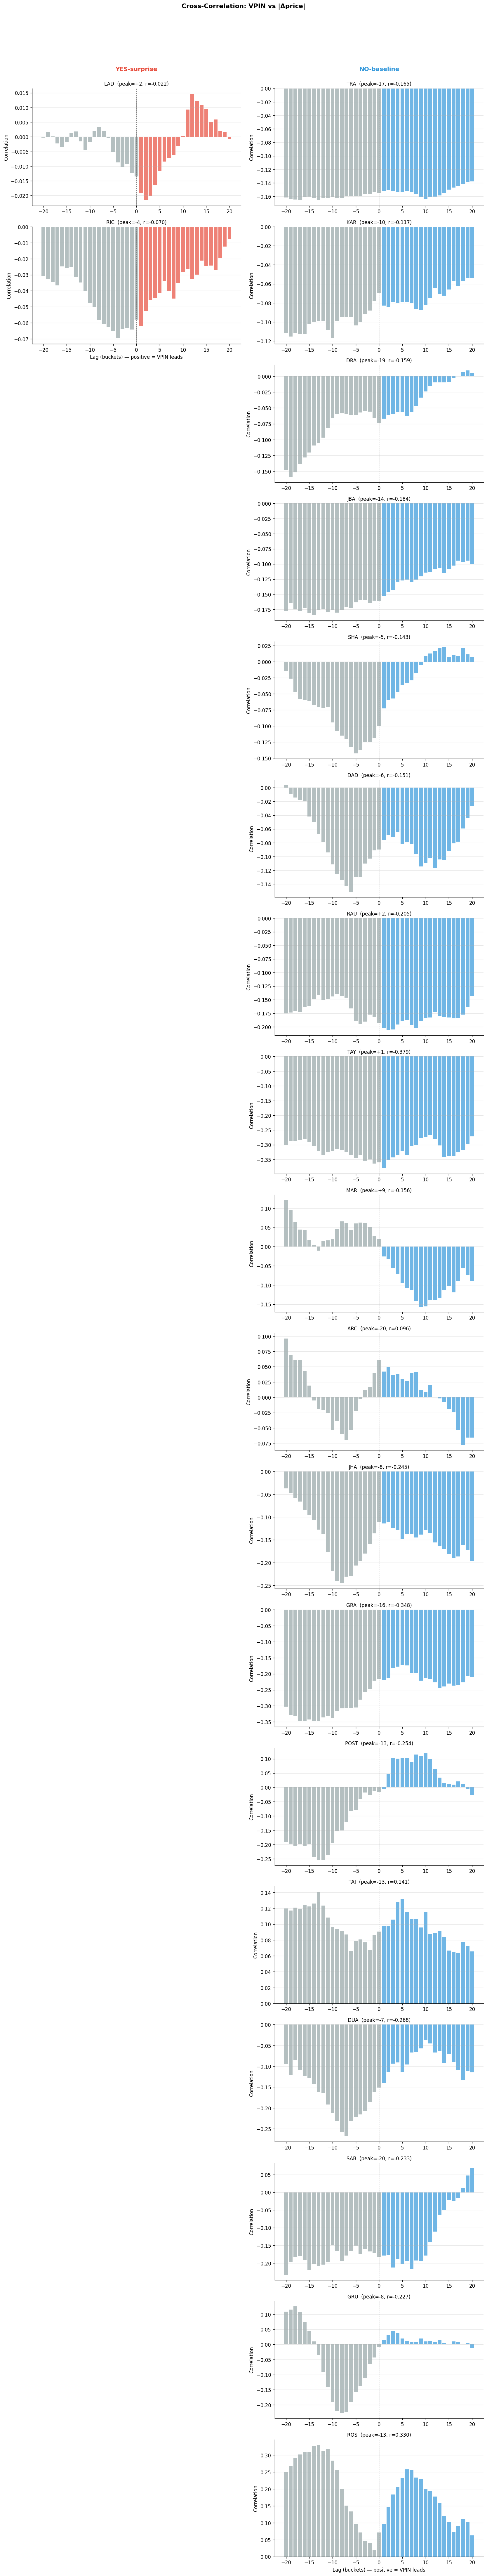

Peak lag summary:
  LAD          (YES-surprise  ): peak lag =  +2  r = -0.022
  RIC          (YES-surprise  ): peak lag =  -4  r = -0.070
  BAD          (YES-public    ): peak lag = +13  r = 0.251
  TRA          (NO-baseline   ): peak lag = -17  r = -0.165
  KAR          (NO-baseline   ): peak lag = -10  r = -0.117
  DRA          (NO-baseline   ): peak lag = -19  r = -0.159
  JBA          (NO-baseline   ): peak lag = -14  r = -0.184
  SHA          (NO-baseline   ): peak lag =  -5  r = -0.143
  DAD          (NO-baseline   ): peak lag =  -6  r = -0.151
  RAU          (NO-baseline   ): peak lag =  +2  r = -0.205
  TAY          (NO-baseline   ): peak lag =  +1  r = -0.379
  MAR          (NO-baseline   ): peak lag =  +9  r = -0.156
  ARC          (NO-baseline   ): peak lag = -20  r = 0.096
  JHA          (NO-baseline   ): peak lag =  -8  r = -0.245
  GRA          (NO-baseline   ): peak lag = -16  r = -0.348
  POST         (NO-baseline   ): peak lag = -13  r = -0.254
  TAI          (NO-basel

In [7]:
LAGS = range(-20, 21)
lags_list = list(LAGS)


def cross_correlogram(df):
    """Cross-correlation between VPIN and |delta-price| at lags -20..+20."""
    abs_dprice = df["avg_price"].diff().abs()
    return [df["vpin"].corr(abs_dprice.shift(-k)) for k in lags_list]


# Compute for all markets
ccfs = {ticker: cross_correlogram(market_vpins[ticker]) for ticker in market_vpins}

# Plot: YES-surprise left column, NO-baseline right column
n_rows = max(len(yes_surprise_tickers), len(no_baseline_tickers))

if n_rows > 0:
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows), squeeze=False)

    for col, (tickers, col_title, color) in enumerate([
        (yes_surprise_tickers, "YES-surprise", "#e74c3c"),
        (no_baseline_tickers, "NO-baseline", "#3498db"),
    ]):
        for row, ticker in enumerate(tickers):
            ax = axes[row, col]
            corrs = ccfs[ticker]
            info = market_catalog[ticker]

            bar_colors = [color if l > 0 else "#95a5a6" for l in lags_list]
            ax.bar(lags_list, corrs, color=bar_colors, alpha=0.7)

            peak_idx = int(np.argmax(np.abs(corrs)))
            peak_lag = lags_list[peak_idx]
            peak_corr = corrs[peak_idx]

            ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
            ax.set_title(f"{info['suffix']}  (peak={peak_lag:+d}, r={peak_corr:.3f})", fontsize=10)
            ax.set_ylabel("Correlation")
            ax.grid(True, alpha=0.3, axis="y")

        for row in range(len(tickers), n_rows):
            axes[row, col].set_visible(False)

        axes[0, col].annotate(
            col_title, xy=(0.5, 1.15), xycoords="axes fraction",
            ha="center", fontsize=12, fontweight="bold", color=color,
        )

    for col in range(2):
        last = min(len([yes_surprise_tickers, no_baseline_tickers][col]), n_rows) - 1
        if last >= 0:
            axes[last, col].set_xlabel("Lag (buckets) \u2014 positive = VPIN leads")

    plt.suptitle("Cross-Correlation: VPIN vs |\u0394price|", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# Summary table
print("Peak lag summary:")
for ticker in display_order:
    info = market_catalog[ticker]
    corrs = ccfs[ticker]
    peak_idx = int(np.argmax(np.abs(corrs)))
    peak_lag = lags_list[peak_idx]
    peak_corr = corrs[peak_idx]
    print(f"  {info['suffix']:12s} ({info['group']:14s}): peak lag = {peak_lag:+3d}  r = {peak_corr:.3f}")

## Experiment 5: Volume Decomposition

Is VPIN just a proxy for volume? If total volume explains most of the variation in VPIN (R\u00b2 > 0.9), then VPIN adds little beyond "more trades happened."

**Test:** Regress VPIN on total bucket volume, then re-run the lead-lag analysis on the residual. If the residual VPIN still leads price in YES-surprise markets but not in NO markets, then VPIN captures something beyond volume — presumably order flow toxicity from informed traders.

Volume decomposition (VPIN ~ total_vol):

  LAD         : R²=0.0061  raw_lag= +2  resid_lag= +1  resid_r=-0.026
  RIC         : R²=0.0089  raw_lag= -4  resid_lag= -4  resid_r=-0.069
  BAD         : R²=0.0115  raw_lag=+13  resid_lag=+13  resid_r=0.253
  TRA         : R²=0.0011  raw_lag=-17  resid_lag=-17  resid_r=-0.165
  KAR         : R²=0.0049  raw_lag=-10  resid_lag=-10  resid_r=-0.118
  DRA         : R²=0.0017  raw_lag=-19  resid_lag=-19  resid_r=-0.158
  JBA         : R²=0.0029  raw_lag=-14  resid_lag=-14  resid_r=-0.183
  SHA         : R²=0.0012  raw_lag= -5  resid_lag= -5  resid_r=-0.144
  DAD         : R²=0.0037  raw_lag= -6  resid_lag= -6  resid_r=-0.152
  RAU         : R²=0.0052  raw_lag= +2  resid_lag= +1  resid_r=-0.206
  TAY         : R²=0.0052  raw_lag= +1  resid_lag= +1  resid_r=-0.376
  MAR         : R²=0.0096  raw_lag= +9  resid_lag=+10  resid_r=-0.157
  ARC         : R²=0.0292  raw_lag=-20  resid_lag=-20  resid_r=0.101
  JHA         : R²=0.0082  raw_lag= -8  resid_lag=

,Market,Group,R²,Raw peak lag,Residual peak lag,Residual peak r
0,LAD,YES-surprise,0.0061,2,1,-0.026
1,RIC,YES-surprise,0.0089,-4,-4,-0.069
2,BAD,YES-public,0.0115,13,13,0.253
3,TRA,NO-baseline,0.0011,-17,-17,-0.165
4,KAR,NO-baseline,0.0049,-10,-10,-0.118
5,DRA,NO-baseline,0.0017,-19,-19,-0.158
6,JBA,NO-baseline,0.0029,-14,-14,-0.183
7,SHA,NO-baseline,0.0012,-5,-5,-0.144
8,DAD,NO-baseline,0.0037,-6,-6,-0.152
9,RAU,NO-baseline,0.0052,2,1,-0.206


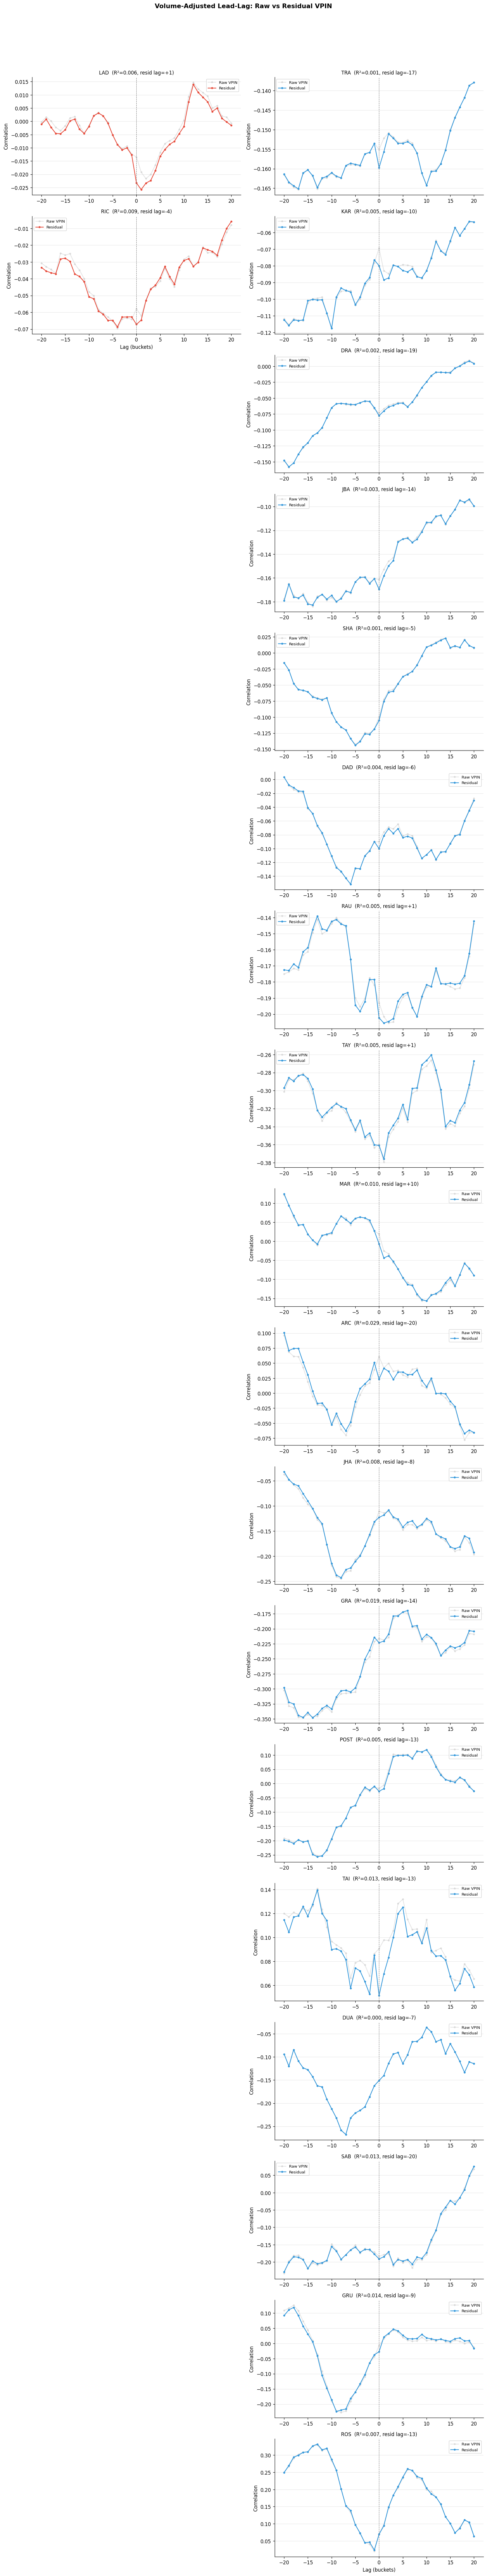

In [8]:
vol_results = {}
for ticker in market_vpins:
    df = market_vpins[ticker]
    slope, intercept, r, p, se = stats.linregress(df["total_vol"], df["vpin"])
    residual = df["vpin"] - (slope * df["total_vol"] + intercept)

    abs_dprice = df["avg_price"].diff().abs()
    resid_corrs = [residual.corr(abs_dprice.shift(-k)) for k in lags_list]

    resid_peak_idx = int(np.argmax(np.abs(resid_corrs)))
    resid_peak_lag = lags_list[resid_peak_idx]
    resid_peak_corr = resid_corrs[resid_peak_idx]

    vol_results[ticker] = {
        "r_squared": r ** 2,
        "p_value": p,
        "resid_corrs": resid_corrs,
        "resid_peak_lag": resid_peak_lag,
        "resid_peak_corr": resid_peak_corr,
    }

# R-squared summary
print("Volume decomposition (VPIN ~ total_vol):\n")
vol_rows = []
for ticker in display_order:
    info = market_catalog[ticker]
    vr = vol_results[ticker]
    corrs = ccfs[ticker]
    raw_peak_idx = int(np.argmax(np.abs(corrs)))
    raw_peak_lag = lags_list[raw_peak_idx]

    vol_rows.append({
        "Market": info["suffix"],
        "Group": info["group"],
        "R\u00b2": f"{vr['r_squared']:.4f}",
        "Raw peak lag": raw_peak_lag,
        "Residual peak lag": vr["resid_peak_lag"],
        "Residual peak r": f"{vr['resid_peak_corr']:.3f}",
    })
    print(
        f"  {info['suffix']:12s}: "
        f"R\u00b2={vr['r_squared']:.4f}  "
        f"raw_lag={raw_peak_lag:+3d}  "
        f"resid_lag={vr['resid_peak_lag']:+3d}  "
        f"resid_r={vr['resid_peak_corr']:.3f}"
    )

display(pd.DataFrame(vol_rows))

# Residual lead-lag plots
n_rows_plot = max(len(yes_surprise_tickers), len(no_baseline_tickers))

if n_rows_plot > 0:
    fig, axes = plt.subplots(n_rows_plot, 2, figsize=(14, 4 * n_rows_plot), squeeze=False)

    for col, (tickers, col_title, color) in enumerate([
        (yes_surprise_tickers, "YES-surprise (residual)", "#e74c3c"),
        (no_baseline_tickers, "NO-baseline (residual)", "#3498db"),
    ]):
        for row, ticker in enumerate(tickers):
            ax = axes[row, col]
            vr = vol_results[ticker]
            info = market_catalog[ticker]
            raw = ccfs[ticker]

            ax.plot(lags_list, raw, "o-", color="#cccccc", markersize=3, alpha=0.5, label="Raw VPIN")
            ax.plot(lags_list, vr["resid_corrs"], "o-", color=color, markersize=3, label="Residual")
            ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
            ax.set_title(
                f"{info['suffix']}  (R\u00b2={vr['r_squared']:.3f}, resid lag={vr['resid_peak_lag']:+d})",
                fontsize=10,
            )
            ax.set_ylabel("Correlation")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3, axis="y")

        for row in range(len(tickers), n_rows_plot):
            axes[row, col].set_visible(False)

    for col in range(2):
        last = min(len([yes_surprise_tickers, no_baseline_tickers][col]), n_rows_plot) - 1
        if last >= 0:
            axes[last, col].set_xlabel("Lag (buckets)")

    plt.suptitle(
        "Volume-Adjusted Lead-Lag: Raw vs Residual VPIN",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.show()

## Synthesis

Aggregate all metrics across the two information regimes. If VPIN detects insider trading, we expect:

| Metric | YES-surprise should show | NO-baseline should show |
|--------|-------------------------|------------------------|
| VPIN distribution | Shifted right of null (KS p < 0.05) | IS the null |
| Spike frequency | Higher than NO pooled rate | ~10% (by construction) |
| Directional accuracy | >> 50% (informed flow) | ~50% (coin flip) |
| Lead-lag peak | Positive (VPIN leads price) | Zero or negative |
| Volume R\u00b2 | < 0.5 (info beyond volume) | Any |
| Residual lead-lag | Still positive | No signal |

In [9]:
summary_rows = []
for ticker in display_order:
    info = market_catalog[ticker]
    df = market_vpins[ticker]
    vr = vol_results[ticker]
    corrs = ccfs[ticker]
    raw_peak_idx = int(np.argmax(np.abs(corrs)))
    raw_peak_lag = lags_list[raw_peak_idx]

    hr_10, n_10 = compute_directional_accuracy(df, spike_threshold, 10)

    summary_rows.append({
        "Market": info["suffix"],
        "Group": info["group"],
        "Result": info["result"],
        "Buckets": len(df),
        "Mean VPIN": round(df["vpin"].mean(), 4),
        "Spike %": round(100 * (df["vpin"] > spike_threshold).sum() / len(df), 1),
        "Hit rate (k=10)": round(hr_10, 3) if not np.isnan(hr_10) else None,
        "Peak lag (raw)": raw_peak_lag,
        "Peak lag (resid)": vr["resid_peak_lag"],
        "Volume R\u00b2": round(vr["r_squared"], 4),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# Group-level comparison
print("\n=== Group-Level Comparison ===\n")
for group in ["YES-surprise", "NO-baseline", "YES-public"]:
    group_rows = [r for r in summary_rows if r["Group"] == group]
    if not group_rows:
        continue
    print(f"{group} (n={len(group_rows)}):")
    for metric in ["Mean VPIN", "Spike %", "Hit rate (k=10)", "Peak lag (raw)", "Volume R\u00b2"]:
        vals = [r[metric] for r in group_rows if r[metric] is not None]
        if vals and all(isinstance(v, (int, float)) for v in vals):
            if len(vals) == 1:
                print(f"  {metric:20s}: {vals[0]:.4f}")
            else:
                print(f"  {metric:20s}: {np.mean(vals):.4f}  (range: {min(vals):.4f} \u2013 {max(vals):.4f})")
    print()

print("=== What to conclude ===\n")
print("Compare YES-surprise to NO-baseline above.")
print("Strong evidence for insider detection:")
print("  - Mean VPIN and Spike % higher for YES-surprise")
print("  - Hit rate >> 50% for YES-surprise, ~50% for NO-baseline")
print("  - Peak lag positive for YES-surprise, zero/negative for NO-baseline")
print("  - Volume R\u00b2 < 0.5 for YES-surprise")
print()
print("If metrics separate cleanly \u2192 Phase 2 (Granger causality, permutation tests, backtesting)")
print("If metrics overlap \u2192 VPIN may not detect insiders in this market structure")

,Market,Group,Result,Buckets,Mean VPIN,Spike %,Hit rate (k=10),Peak lag (raw),Peak lag (resid),Volume R²
0,LAD,YES-surprise,yes,8549,0.8971,8.7,0.521,2,1,0.0061
1,RIC,YES-surprise,yes,2638,0.8668,5.5,0.651,-4,-4,0.0089
2,BAD,YES-public,yes,207,0.8215,4.3,0.286,13,13,0.0115
3,TRA,NO-baseline,no,18473,0.8984,12.4,0.503,-17,-17,0.0011
4,KAR,NO-baseline,no,3848,0.8570,5.5,0.646,-10,-10,0.0049
5,DRA,NO-baseline,no,2374,0.8959,12.6,0.362,-19,-19,0.0017
6,JBA,NO-baseline,no,2432,0.8482,3.6,0.528,-14,-14,0.0029
7,SHA,NO-baseline,no,1160,0.9230,23.4,0.540,-5,-5,0.0012
8,DAD,NO-baseline,no,1280,0.8980,16.2,0.427,-6,-6,0.0037
9,RAU,NO-baseline,no,1264,0.8032,2.6,0.600,2,1,0.0052



=== Group-Level Comparison ===

YES-surprise (n=2):
  Mean VPIN           : 0.8820  (range: 0.8668 – 0.8971)
  Spike %             : 7.1000  (range: 5.5000 – 8.7000)
  Hit rate (k=10)     : 0.5860  (range: 0.5210 – 0.6510)
  Peak lag (raw)      : -1.0000  (range: -4.0000 – 2.0000)
  Volume R²           : 0.0075  (range: 0.0061 – 0.0089)

NO-baseline (n=18):
  Mean VPIN           : 0.8489  (range: 0.7594 – 0.9230)
  Spike %             : 6.2333  (range: 0.0000 – 23.4000)
  Hit rate (k=10)     : 0.5503  (range: 0.3620 – 0.7500)
  Peak lag (raw)      : -9.8333  (range: -20.0000 – 9.0000)
  Volume R²           : 0.0080  (range: 0.0000 – 0.0292)

YES-public (n=1):
  Mean VPIN           : 0.8215
  Spike %             : 4.3000
  Hit rate (k=10)     : 0.2860
  Peak lag (raw)      : 13.0000
  Volume R²           : 0.0115

=== What to conclude ===

Compare YES-surprise to NO-baseline above.
Strong evidence for insider detection:
  - Mean VPIN and Spike % higher for YES-surprise
  - Hit rate >> 